---
subject: Programmation
venue: OCaml
title: "Exercises"
subtitle: OCaml
short_title: ""
authors:
  - name: OCaml.org
license: CC-BY-4.0
---

Extracted from : [https://ocaml.org/exercises](https://ocaml.org/exercises)

:::{note} Level
🟢 Beginner
🟡 Intermediate
🔴 Advanced
:::

:::{exercise} Tail of a List 🟢
:label: ex1

**Tags:** `list`

Write a function `last : 'a list -> 'a option` that returns the last element of a list

```ocaml
# last ["a" ; "b" ; "c" ; "d"];;
- : string option = Some "d"
# last [];;
- : 'a option = None
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex1
:class: dropdown
:label: sol1

```ocaml
# let rec last = function 
  | [] -> None
  | [ x ] -> Some x
  | _ :: t -> last t;;
val last : 'a list -> 'a option = <fun>
```
:::

:::{exercise} Last Two Elements of a List 🟢
:label: ex2

**Tags:** `list`

Find the last two (last and penultimate) elements of a list.

```ocaml
# last_two ["a"; "b"; "c"; "d"];;
- : (string * string) option = Some ("c", "d")
# last_two ["a"];;
- : (string * string) option = None
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex2
:class: dropdown
:label: sol2

```ocaml
# let rec last_two = function
    | [] | [_] -> None
    | [x; y] -> Some (x,y)
    | _ :: t -> last_two t;;
val last_two : 'a list -> ('a * 'a) option = <fun>
```
:::

:::{exercise} N'th Element of a List 🟢
:label: ex3

**Tags:** `list`

Find the N'th element of a list.

```ocaml
# at 2 ["a"; "b"; "c"; "d"; "e"];;
- : string option = Some "c"
# at 2 ["a"];;
- : string option = None
```

**Remark:** OCaml has `List.nth` which numbers elements from `0` and
raises an exception if the index is out of bounds.

```ocaml
# List.nth ["a"; "b"; "c"; "d"; "e"] 2;;
- : string = "c"
# List.nth ["a"] 2;;
Exception: Failure "nth".
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex3
:class: dropdown
:label: sol3

```ocaml
# let rec at k = function
    | [] -> None
    | h :: t -> if k = 0 then Some h else at (k - 1) t;;
val at : int -> 'a list -> 'a option = <fun>
```
:::

:::{exercise} Length of a List 🟢
:label: ex4

**Tags:** `list`

Find the number of elements of a list.

OCaml standard library has `List.length` but we ask that you reimplement
it. Bonus for a [tail recursive](http://en.wikipedia.org/wiki/Tail_call)
solution.

```ocaml
# length ["a"; "b"; "c"];;
- : int = 3
# length [];;
- : int = 0
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex4
:class: dropdown
:label: sol4

```ocaml
# let length list =
    let rec aux n = function
      | [] -> n
      | _ :: t -> aux (n + 1) t
    in
    aux 0 list;;
val length : 'a list -> int = <fun>
```
:::

:::{exercise} Reverse a List 🟢
:label: ex5

**Tags:** `list`

Reverse a list.

OCaml standard library has `List.rev` but we ask that you reimplement
it.


```ocaml
# rev ["a"; "b"; "c"];;
- : string list = ["c"; "b"; "a"]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex5
:class: dropdown
:label: sol5

```ocaml
# let rev list =
    let rec aux acc = function
      | [] -> acc
      | h :: t -> aux (h :: acc) t
    in
    aux [] list;;
val rev : 'a list -> 'a list = <fun>
```
:::

:::{exercise} Palindrome 🟢
:label: ex6

**Tags:** `list`

Find out whether a list is a palindrome.

**Hint:** A palindrome is its own reverse.

```ocaml
# is_palindrome ["x"; "a"; "m"; "a"; "x"];;
- : bool = true
# not (is_palindrome ["a"; "b"]);;
- : bool = true
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex6
:class: dropdown
:label: sol6

```ocaml
# let is_palindrome list =
    (* One can use either the rev function from the previous problem, or the built-in List.rev *)
    list = List.rev list;;
val is_palindrome : 'a list -> bool = <fun>
```
:::

:::{exercise} Flatten a List 🟡
:label: ex7

**Tags:** `list`

Flatten a nested list structure.

```ocaml
type 'a node =
  | One of 'a 
  | Many of 'a node list
```

```ocaml
# flatten [One "a"; Many [One "b"; Many [One "c" ;One "d"]; One "e"]];;
- : string list = ["a"; "b"; "c"; "d"; "e"]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex7
:class: dropdown
:label: sol7

```ocaml
# type 'a node =
    | One of 'a 
    | Many of 'a node list;;
type 'a node = One of 'a | Many of 'a node list
# (* This function traverses the list, prepending any encountered elements
    to an accumulator, which flattens the list in inverse order. It can
    then be reversed to obtain the actual flattened list. *);;
# let flatten list =
    let rec aux acc = function
      | [] -> acc
      | One x :: t -> aux (x :: acc) t
      | Many l :: t -> aux (aux acc l) t
    in
    List.rev (aux [] list);;
val flatten : 'a node list -> 'a list = <fun>
```
:::

:::{exercise} Eliminate Duplicates 🟡
:label: ex8

**Tags:** `list`

Eliminate consecutive duplicates of list elements.

```ocaml
# compress ["a"; "a"; "a"; "a"; "b"; "c"; "c"; "a"; "a"; "d"; "e"; "e"; "e"; "e"];;
- : string list = ["a"; "b"; "c"; "a"; "d"; "e"]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex8
:class: dropdown
:label: sol8

```ocaml
# let rec compress = function
    | a :: (b :: _ as t) -> if a = b then compress t else a :: compress t
    | smaller -> smaller;;
val compress : 'a list -> 'a list = <fun>
```
:::

:::{exercise} Pack Consecutive Duplicates 🟡
:label: ex9

**Tags:** `list`

Pack consecutive duplicates of list elements into sublists.

```ocaml
# pack ["a"; "a"; "a"; "a"; "b"; "c"; "c"; "a"; "a"; "d"; "d"; "e"; "e"; "e"; "e"];;
- : string list list =
[["a"; "a"; "a"; "a"]; ["b"]; ["c"; "c"]; ["a"; "a"]; ["d"; "d"];
 ["e"; "e"; "e"; "e"]]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex9
:class: dropdown
:label: sol9

```ocaml
# let pack list =
    let rec aux current acc = function
      | [] -> []    (* Can only be reached if original list is empty *)
      | [x] -> (x :: current) :: acc
      | a :: (b :: _ as t) ->
         if a = b then aux (a :: current) acc t
         else aux [] ((a :: current) :: acc) t  in
    List.rev (aux [] [] list);;
val pack : 'a list -> 'a list list = <fun>
```
:::

:::{exercise} Run-Length Encoding 🟢
:label: ex10

**Tags:** `list`

If you need so, refresh your memory about
[run-length encoding](http://en.wikipedia.org/wiki/Run-length_encoding).

Here is an example:

```ocaml
# encode ["a"; "a"; "a"; "a"; "b"; "c"; "c"; "a"; "a"; "d"; "e"; "e"; "e"; "e"];;
- : (int * string) list =
[(4, "a"); (1, "b"); (2, "c"); (2, "a"); (1, "d"); (4, "e")]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex10
:class: dropdown
:label: sol10

```ocaml
# let encode list =
    let rec aux count acc = function
      | [] -> [] (* Can only be reached if original list is empty *)
      | [x] -> (count + 1, x) :: acc
      | a :: (b :: _ as t) -> if a = b then aux (count + 1) acc t
                              else aux 0 ((count + 1, a) :: acc) t in
    List.rev (aux 0 [] list);;
val encode : 'a list -> (int * 'a) list = <fun>
```
:::

:::{exercise} Modified Run-Length Encoding 🟢
:label: ex11

**Tags:** `list`

Modify the result of the previous problem in such a way that if an
element has no duplicates it is simply copied into the result list. Only
elements with duplicates are transferred as (N E) lists.

Since OCaml lists are homogeneous, one needs to define a type to hold
both single elements and sub-lists.

<!-- $MDX skip -->
```ocaml
type 'a rle =
  | One of 'a
  | Many of int * 'a
```

```ocaml
# encode ["a"; "a"; "a"; "a"; "b"; "c"; "c"; "a"; "a"; "d"; "e"; "e"; "e"; "e"];;
- : string rle list =
[Many (4, "a"); One "b"; Many (2, "c"); Many (2, "a"); One "d";
 Many (4, "e")]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex11
:class: dropdown
:label: sol11

```ocaml
# type 'a rle =
  | One of 'a
  | Many of int * 'a;;
type 'a rle = One of 'a | Many of int * 'a
# let encode l =
    let create_tuple cnt elem =
      if cnt = 1 then One elem
      else Many (cnt, elem) in
    let rec aux count acc = function
      | [] -> []
      | [x] -> (create_tuple (count + 1) x) :: acc
      | hd :: (snd :: _ as tl) ->
          if hd = snd then aux (count + 1) acc tl
          else aux 0 ((create_tuple (count + 1) hd) :: acc) tl in
      List.rev (aux 0 [] l);;
val encode : 'a list -> 'a rle list = <fun>
```
:::

:::{exercise} Decode a Run-Length Encoded List 🟡
:label: ex12

**Tags:** `list`

Given a run-length code list generated as specified in the previous
problem, construct its uncompressed version.

```ocaml
#  decode [Many (4, "a"); One "b"; Many (2, "c"); Many (2, "a"); One "d"; Many (4, "e")];;
- : string list =
["a"; "a"; "a"; "a"; "b"; "c"; "c"; "a"; "a"; "d"; "e"; "e"; "e"; "e"]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex12
:class: dropdown
:label: sol12

```ocaml
# let decode list =
    let rec many acc n x =
      if n = 0 then acc else many (x :: acc) (n - 1) x
    in
    let rec aux acc = function
      | [] -> acc
      | One x :: t -> aux (x :: acc) t
      | Many (n, x) :: t -> aux (many acc n x) t
    in
      aux [] (List.rev list);;
val decode : 'a rle list -> 'a list = <fun>
```
:::

:::{exercise} Run-Length Encoding of a List (Direct Solution) 🟡
:label: ex13

**Tags:** `list`

Implement the so-called run-length encoding data compression method
directly. I.e. don't explicitly create the sublists containing the
duplicates, as in problem "[Pack consecutive duplicates of list elements into sublists](#9)", but only count them. As in problem
"[Modified run-length encoding](#10)", simplify the result list by replacing the singleton lists (1 X) by X.

```ocaml
# encode ["a";"a";"a";"a";"b";"c";"c";"a";"a";"d";"e";"e";"e";"e"];;
- : string rle list =
[Many (4, "a"); One "b"; Many (2, "c"); Many (2, "a"); One "d";
 Many (4, "e")]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex13
:class: dropdown
:label: sol13

```ocaml
# let encode list =
    let rle count x = if count = 0 then One x else Many (count + 1, x) in
    let rec aux count acc = function
      | [] -> [] (* Can only be reached if original list is empty *)
      | [x] -> rle count x :: acc
      | a :: (b :: _ as t) -> if a = b then aux (count + 1) acc t
                              else aux 0 (rle count a :: acc) t
    in
      List.rev (aux 0 [] list);;
val encode : 'a list -> 'a rle list = <fun>
```
:::

:::{exercise} Duplicate the Elements of a List 🟢
:label: ex14

**Tags:** `list`

Duplicate the elements of a list.

```ocaml
# duplicate ["a"; "b"; "c"; "c"; "d"];;
- : string list = ["a"; "a"; "b"; "b"; "c"; "c"; "c"; "c"; "d"; "d"]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex14
:class: dropdown
:label: sol14

```ocaml
# let rec duplicate = function
    | [] -> []
    | h :: t -> h :: h :: duplicate t;;
val duplicate : 'a list -> 'a list = <fun>
```
:::

:::{exercise} Replicate the Elements of a List a Given Number of Times 🟡
:label: ex15

**Tags:** `list`

Replicate the elements of a list a given number of times.

```ocaml
# replicate ["a"; "b"; "c"] 3;;
- : string list = ["a"; "a"; "a"; "b"; "b"; "b"; "c"; "c"; "c"]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex15
:class: dropdown
:label: sol15

```ocaml
# let replicate list n =
    let rec prepend n acc x =
      if n = 0 then acc else prepend (n-1) (x :: acc) x in
    let rec aux acc = function
      | [] -> acc
      | h :: t -> aux (prepend n acc h) t in
    (* This could also be written as:
       List.fold_left (prepend n) [] (List.rev list) *)
    aux [] (List.rev list);;
val replicate : 'a list -> int -> 'a list = <fun>
```
:::

:::{exercise} Drop Every N'th Element From a List 🟡
:label: ex16

**Tags:** `list`

Drop every N'th element from a list.

```ocaml
# drop ["a"; "b"; "c"; "d"; "e"; "f"; "g"; "h"; "i"; "j"] 3;;
- : string list = ["a"; "b"; "d"; "e"; "g"; "h"; "j"]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex16
:class: dropdown
:label: sol16

```ocaml
# let drop list n =
    let rec aux i = function
      | [] -> []
      | h :: t -> if i = n then aux 1 t else h :: aux (i + 1) t  in
    aux 1 list;;
val drop : 'a list -> int -> 'a list = <fun>
```
:::

:::{exercise} Split a List Into Two Parts; The Length of the First Part Is Given 🟢
:label: ex17

**Tags:** `list`

Split a list into two parts; the length of the first part is given.

If the length of the first part is longer than the entire list, then the
first part is the list and the second part is empty.

```ocaml
# split ["a"; "b"; "c"; "d"; "e"; "f"; "g"; "h"; "i"; "j"] 3;;
- : string list * string list =
(["a"; "b"; "c"], ["d"; "e"; "f"; "g"; "h"; "i"; "j"])
# split ["a"; "b"; "c"; "d"] 5;;
- : string list * string list = (["a"; "b"; "c"; "d"], [])
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex17
:class: dropdown
:label: sol17

```ocaml
# let split list n =
    let rec aux i acc = function
      | [] -> List.rev acc, []
      | h :: t as l -> if i = 0 then List.rev acc, l
                       else aux (i - 1) (h :: acc) t 
    in
      aux n [] list;;
val split : 'a list -> int -> 'a list * 'a list = <fun>
```
:::

:::{exercise} Extract a Slice From a List 🟡
:label: ex18

**Tags:** `list`

Given two indices, `i` and `k`, the slice is the list containing the
elements between the `i`'th and `k`'th element of the original list
(both limits included). Start counting the elements with 0 (this is the
way the `List` module numbers elements).

```ocaml
# slice ["a"; "b"; "c"; "d"; "e"; "f"; "g"; "h"; "i"; "j"] 2 6;;
- : string list = ["c"; "d"; "e"; "f"; "g"]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex18
:class: dropdown
:label: sol18

```ocaml
# let slice list i k =
    let rec take n = function
      | [] -> []
      | h :: t -> if n = 0 then [] else h :: take (n - 1) t
    in
    let rec drop n = function
      | [] -> []
      | h :: t as l -> if n = 0 then l else drop (n - 1) t
    in
    take (k - i + 1) (drop i list);;
val slice : 'a list -> int -> int -> 'a list = <fun>
```
:::

:::{exercise} Rotate a List N Places to the Left 🟡
:label: ex19

**Tags:** `list`

Rotate a list N places to the left.

```ocaml
# rotate ["a"; "b"; "c"; "d"; "e"; "f"; "g"; "h"] 3;;
- : string list = ["d"; "e"; "f"; "g"; "h"; "a"; "b"; "c"]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex19
:class: dropdown
:label: sol19

```ocaml
# let split list n =
    let rec aux i acc = function
      | [] -> List.rev acc, []
      | h :: t as l -> if i = 0 then List.rev acc, l
                       else aux (i - 1) (h :: acc) t  in
    aux n [] list

  let rotate list n =
    let len = List.length list in
    (* Compute a rotation value between 0 and len - 1 *)
    let n = if len = 0 then 0 else (n mod len + len) mod len in
    if n = 0 then list
    else let a, b = split list n in b @ a;;
val split : 'a list -> int -> 'a list * 'a list = <fun>
val rotate : 'a list -> int -> 'a list = <fun>
```
:::

:::{exercise} Remove the K'th Element From a List 🟢
:label: ex20

**Tags:** `list`

Remove the K'th element from a list.

The first element of the list is numbered 0, the second 1,...

```ocaml
# remove_at 1 ["a"; "b"; "c"; "d"];;
- : string list = ["a"; "c"; "d"]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex20
:class: dropdown
:label: sol20

```ocaml
# let rec remove_at n = function
    | [] -> []
    | h :: t -> if n = 0 then t else h :: remove_at (n - 1) t;;
val remove_at : int -> 'a list -> 'a list = <fun>
```
:::

:::{exercise} Insert an Element at a Given Position Into a List 🟢
:label: ex21

**Tags:** `list`

Start counting list elements with 0.  If the position is larger or
equal to the length of the list, insert the element at the end.  (The
behavior is unspecified if the position is negative.)

```ocaml
# insert_at "alfa" 1 ["a"; "b"; "c"; "d"];;
- : string list = ["a"; "alfa"; "b"; "c"; "d"]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex21
:class: dropdown
:label: sol21

```ocaml
# let rec insert_at x n = function
    | [] -> [x]
    | h :: t as l -> if n = 0 then x :: l else h :: insert_at x (n - 1) t;;
val insert_at : 'a -> int -> 'a list -> 'a list = <fun>
```
:::

:::{exercise} Create a List Containing All Integers Within a Given Range 🟢
:label: ex22

**Tags:** `list`

If first argument is greater than second, produce a list in decreasing
order.

```ocaml
# range 4 9;;
- : int list = [4; 5; 6; 7; 8; 9]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex22
:class: dropdown
:label: sol22

```ocaml
# let range a b =
    let rec aux a b =
      if a > b then [] else a :: aux (a + 1) b
    in
      if a > b then List.rev (aux b a) else aux a b;;
val range : int -> int -> int list = <fun>
```
:::

:::{exercise} Extract a Given Number of Randomly Selected Elements From a List 🟡
:label: ex23

**Tags:** `list`

The selected items shall be returned in a list. We use the `Random`
module but and initialise it with `Random.init 0` at the start of 
the function for reproducibility and validate the solution. To make the function truly random, however,
one should remove the call to `Random.init 0`

```ocaml
# rand_select ["a"; "b"; "c"; "d"; "e"; "f"; "g"; "h"] 3;;
- : string list = ["e"; "c"; "g"]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex23
:class: dropdown
:label: sol23

```ocaml
# let rand_select list n =
    Random.init 0;
    let rec extract acc n = function
      | [] -> raise Not_found
      | h :: t -> if n = 0 then (h, acc @ t) else extract (h :: acc) (n - 1) t
    in
    let extract_rand list len =
      extract [] (Random.int len) list
    in
    let rec aux n acc list len =
      if n = 0 then acc else
        let picked, rest = extract_rand list len in
        aux (n - 1) (picked :: acc) rest (len - 1)
    in
    let len = List.length list in
      aux (min n len) [] list len;;
val rand_select : 'a list -> int -> 'a list = <fun>
```
:::

:::{exercise} Lotto: Draw N Different Random Numbers From the Set 1..M 🟢
:label: ex24

**Tags:** `list`

Draw N different random numbers from the set `1..M`.

The selected numbers shall be returned in a list.

```ocaml
# lotto_select 6 49;;
- : int list = [20; 28; 45; 16; 24; 38]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex24
:class: dropdown
:label: sol24

```ocaml
# (* [range] and [rand_select] defined in problems above *)
  let lotto_select n m = rand_select (range 1 m) n;;
val lotto_select : int -> int -> int list = <fun>
```
:::

:::{exercise} Generate a Random Permutation of the Elements of a List 🟢
:label: ex25

**Tags:** `list`

Generate a random permutation of the elements of a list.

```ocaml
# permutation ["a"; "b"; "c"; "d"; "e"; "f"];;
- : string list = ["c"; "d"; "f"; "e"; "b"; "a"]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex25
:class: dropdown
:label: sol25

```ocaml
# let permutation list =
    let rec extract acc n = function
      | [] -> raise Not_found
      | h :: t -> if n = 0 then (h, acc @ t) else extract (h :: acc) (n - 1) t
    in
    let extract_rand list len =
      extract [] (Random.int len) list
    in
    let rec aux acc list len =
      if len = 0 then acc else
        let picked, rest = extract_rand list len in
        aux (picked :: acc) rest (len - 1)
    in
    aux [] list (List.length list);;
val permutation : 'a list -> 'a list = <fun>
```
:::

:::{exercise} Generate the Combinations of K Distinct Objects Chosen From the N Elements of a List 🟡
:label: ex26

**Tags:** `list`

Generate the combinations of K distinct objects chosen from the N elements of a list.

In how many ways can a committee of 3 be chosen from a group of 12
people? We all know that there are C(12,3) = 220 possibilities (C(N,K)
denotes the well-known binomial coefficients). For pure mathematicians,
this result may be great. But we want to really generate all the
possibilities in a list.

```ocaml
# extract 2 ["a"; "b"; "c"; "d"];;
- : string list list =
[["a"; "b"]; ["a"; "c"]; ["a"; "d"]; ["b"; "c"]; ["b"; "d"]; ["c"; "d"]]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex26
:class: dropdown
:label: sol26

```ocaml
# let rec extract k list =
    if k <= 0 then [[]]
    else match list with
         | [] -> []
         | h :: tl ->
            let with_h = List.map (fun l -> h :: l) (extract (k - 1) tl) in
            let without_h = extract k tl in
            with_h @ without_h;;
val extract : int -> 'a list -> 'a list list = <fun>
```
:::

:::{exercise} Group the Elements of a Set Into Disjoint Subsets 🟡
:label: ex27

**Tags:** `list`

Group the elements of a set into disjoint subsets

1. In how many ways can a group of 9 people work in 3 disjoint subgroups 
of 2, 3 and 4 persons? Write a function that generates all the
possibilities and returns them in a list.
2. Generalize the above function in a way that we can specify a list of
group sizes and the function will return a list of groups.

```ocaml
# group ["a"; "b"; "c"; "d"] [2; 1];;
- : string list list list =
[[["a"; "b"]; ["c"]]; [["a"; "c"]; ["b"]]; [["b"; "c"]; ["a"]];
 [["a"; "b"]; ["d"]]; [["a"; "c"]; ["d"]]; [["b"; "c"]; ["d"]];
 [["a"; "d"]; ["b"]]; [["b"; "d"]; ["a"]]; [["a"; "d"]; ["c"]];
 [["b"; "d"]; ["c"]]; [["c"; "d"]; ["a"]]; [["c"; "d"]; ["b"]]]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex27
:class: dropdown
:label: sol27

```ocaml
# (* This implementation is less streamlined than the one-extraction
  version, because more work is done on the lists after each
  transform to prepend the actual items. The end result is cleaner
  in terms of code, though. *)

  let group list sizes =
    let initial = List.map (fun size -> size, []) sizes in
    (* The core of the function. Prepend accepts a list of groups,
        each with the number of items that should be added, and
        prepends the item to every group that can support it, thus
        turning [1,a ; 2,b ; 0,c] into [ [0,x::a ; 2,b ; 0,c ];
        [1,a ; 1,x::b ; 0,c]; [ 1,a ; 2,b ; 0,c ]]

        Again, in the prolog language (for which these questions are
        originally intended), this function is a whole lot simpler.  *)
  let prepend p list =
    let emit l acc = l :: acc in
    let rec aux emit acc = function
      | [] -> emit [] acc
      | (n, l) as h :: t ->
         let acc = if n > 0 then emit ((n - 1, p :: l) :: t) acc
                   else acc in
         aux (fun l acc -> emit (h :: l) acc) acc t
    in
    aux emit [] list
  in
  let rec aux = function
    | [] -> [initial]
    | h :: t -> List.concat_map (prepend h) (aux t)
  in
  let all = aux list in
  (* Don't forget to eliminate all group sets that have non-full
     groups *)
  let complete = List.filter (List.for_all (fun (x, _) -> x = 0)) all in
    List.map (List.map snd) complete;;
val group : 'a list -> int list -> 'a list list list = <fun>
```
:::

:::{exercise} Sorting a List of Lists According to Length of Sublists 🟡
:label: ex28

**Tags:** `list`

Sorting a list of lists according to length of sublists.

1. We suppose that a list contains elements that are lists themselves.
The objective is to sort the elements of this list according to their
length. E.g. short lists first, longer lists later, or vice versa.

2. Again, we suppose that a list contains elements that are lists
themselves. But this time the objective is to sort the elements of this
list according to their **length frequency**; i.e., in the default,
where sorting is done ascendingly, lists with rare lengths are placed
first, others with a more frequent length come later.

```ocaml
# length_sort [["a"; "b"; "c"]; ["d"; "e"]; ["f"; "g"; "h"]; ["d"; "e"];
             ["i"; "j"; "k"; "l"]; ["m"; "n"]; ["o"]];;
- : string list list =
[["o"]; ["d"; "e"]; ["d"; "e"]; ["m"; "n"]; ["a"; "b"; "c"]; ["f"; "g"; "h"];
 ["i"; "j"; "k"; "l"]]
# frequency_sort [["a"; "b"; "c"]; ["d"; "e"]; ["f"; "g"; "h"]; ["d"; "e"];
                ["i"; "j"; "k"; "l"]; ["m"; "n"]; ["o"]];;
- : string list list =
[["i"; "j"; "k"; "l"]; ["o"]; ["a"; "b"; "c"]; ["f"; "g"; "h"]; ["d"; "e"];
 ["d"; "e"]; ["m"; "n"]]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex28
:class: dropdown
:label: sol28

```ocaml
(* We might not be allowed to use built-in List.sort, so here's an
   eight-line implementation of insertion sort — O(n²) time
   complexity. *)
let rec insert cmp e = function
  | [] -> [e]
  | h :: t as l -> if cmp e h <= 0 then e :: l else h :: insert cmp e t

let rec sort cmp = function
  | [] -> []
  | h :: t -> insert cmp h (sort cmp t)

(* Sorting according to length : prepend length, sort, remove length *)
let length_sort lists =
  let lists = List.map (fun list -> List.length list, list) lists in
  let lists = sort (fun a b -> compare (fst a) (fst b)) lists in
  List.map snd lists
;;

(* Sorting according to length frequency : prepend frequency, sort,
   remove frequency. Frequencies are extracted by sorting lengths
   and applying RLE to count occurrences of each length (see problem
   "Run-length encoding of a list.") *)
let rle list =
  let rec aux count acc = function
    | [] -> [] (* Can only be reached if original list is empty *)
    | [x] -> (x, count + 1) :: acc
    | a :: (b :: _ as t) ->
       if a = b then aux (count + 1) acc t
       else aux 0 ((a, count + 1) :: acc) t in
  aux 0 [] list

let frequency_sort lists =
  let lengths = List.map List.length lists in
  let freq = rle (sort compare lengths) in
  let by_freq =
    List.map (fun list -> List.assoc (List.length list) freq , list) lists in
  let sorted = sort (fun a b -> compare (fst a) (fst b)) by_freq in
  List.map snd sorted
```
:::

:::{exercise} Determine Whether a Given Integer Number Is Prime 🟡
:label: ex29

**Tags:** `arithmetic`

Determine whether a given integer number is prime.

```ocaml
# not (is_prime 1);;
- : bool = true
# is_prime 7;;
- : bool = true
# not (is_prime 12);;
- : bool = true
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex29
:class: dropdown
:label: sol29

```ocaml
# let is_prime n =
    let n = abs n in
    let rec is_not_divisor d =
      d * d > n || (n mod d <> 0 && is_not_divisor (d + 1)) in
    n > 1 && is_not_divisor 2;;
val is_prime : int -> bool = <fun>
```
:::

:::{exercise} Determine the Greatest Common Divisor of Two Positive Integer Numbers 🟡
:label: ex30

**Tags:** `arithmetic`

Determine the greatest common divisor of two positive integer numbers.

Use Euclid's algorithm.

```ocaml
# gcd 13 27;;
- : int = 1
# gcd 20536 7826;;
- : int = 2
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex30
:class: dropdown
:label: sol30

```ocaml
# let rec gcd a b =
    if b = 0 then a else gcd b (a mod b);;
val gcd : int -> int -> int = <fun>
```
:::

:::{exercise} Determine Whether Two Positive Integer Numbers Are Coprime 🟢
:label: ex31

**Tags:** `arithmetic`

Determine whether two positive integer numbers are coprime.

Two numbers are coprime if their greatest common divisor equals 1.

```ocaml
# coprime 13 27;;
- : bool = true
# not (coprime 20536 7826);;
- : bool = true
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex31
:class: dropdown
:label: sol31

```ocaml
# (* [gcd] is defined in the previous question *)
  let coprime a b = gcd a b = 1;;
val coprime : int -> int -> bool = <fun>
```
:::

:::{exercise} Calculate Euler's Totient Function Φ(m) 🟡
:label: ex32

**Tags:** `arithmetic`

Euler's so-called totient function φ(m) is defined as the number of
positive integers r (1 ≤ r < m) that are coprime to m. We let φ(1) = 1.

Find out what the value of φ(m) is if m is a prime number.  Euler's
totient function plays an important role in one of the most widely used
public key cryptography methods (RSA). In this exercise you should use
the most primitive method to calculate this function (there are smarter
ways that we shall discuss later).

```ocaml
# phi 10;;
- : int = 4
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex32
:class: dropdown
:label: sol32

```ocaml
# (* [coprime] is defined in the previous question *)
  let phi n =
    let rec count_coprime acc d =
      if d < n then
        count_coprime (if coprime n d then acc + 1 else acc) (d + 1)
      else acc
    in
      if n = 1 then 1 else count_coprime 0 1;;
val phi : int -> int = <fun>
```
:::

:::{exercise} Determine the Prime Factors of a Given Positive Integer 🟡
:label: ex33

**Tags:** `arithmetic`

Construct a flat list containing the prime factors in ascending order.


```ocaml
# factors 315;;
- : int list = [3; 3; 5; 7]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex33
:class: dropdown
:label: sol33

```ocaml
# (* Recall that d divides n iff [n mod d = 0] *)
  let factors n =
    let rec aux d n =
      if n = 1 then [] else
        if n mod d = 0 then d :: aux d (n / d) else aux (d + 1) n
    in
      aux 2 n;;
val factors : int -> int list = <fun>
```
:::

:::{exercise} Determine the Prime Factors of a Given Positive Integer (2) 🟡
:label: ex34

**Tags:** `arithmetic`

Construct a list containing the prime factors and their multiplicity.

**Hint:** The problem is similar to problem
[Run-length encoding of a list (direct solution)](#10).

```ocaml
# factors 315;;
- : (int * int) list = [(3, 2); (5, 1); (7, 1)]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex34
:class: dropdown
:label: sol34

```ocaml
# let factors n =
    let rec aux d n =
      if n = 1 then [] else
        if n mod d = 0 then
          match aux d (n / d) with
          | (h, n) :: t when h = d -> (h, n + 1) :: t
          | l -> (d, 1) :: l
        else aux (d + 1) n
    in
      aux 2 n;;
val factors : int -> (int * int) list = <fun>
```
:::

:::{exercise} Calculate Euler's Totient Function Φ(m) (Improved) 🟡
:label: ex35

**Tags:** `arithmetic`

See problem "[Calculate Euler&#39;s totient function φ(m)](#34)" for
the definition of Euler's totient function. If the list of the prime
factors of a number m is known in the form of the previous problem then
the function phi(m) can be efficiently calculated as follows: Let
`[(p1, m1); (p2, m2); (p3, m3); ...]` be the list of prime factors
(and their multiplicities) of a given number m. Then φ(m) can be
calculated with the following formula:

φ(m) = (p1 - 1) × p1<sup>m1 - 1</sup> × (p2 - 1) ×
p2<sup>m2 - 1</sup> × (p3 - 1) × p3<sup>m3 - 1</sup> × ⋯

```ocaml
# phi_improved 10;;
- : int = 4
# phi_improved 13;;
- : int = 12
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex35
:class: dropdown
:label: sol35

```ocaml
(* Naive power function. *)
let rec pow n p = if p < 1 then 1 else n * pow n (p - 1)

(* [factors] is defined in the previous question. *)
let phi_improved n =
  let rec aux acc = function
    | [] -> acc
    | (p, m) :: t -> aux ((p - 1) * pow p (m - 1) * acc) t
  in
    aux 1 (factors n)
```
:::

:::{exercise} Compare the Two Methods of Calculating Euler's Totient Function 🟢
:label: ex36

**Tags:** `arithmetic`

Use the solutions of problems 
"[Calculate Euler&#39;s totient function φ(m)](#34)" and
"[Calculate Euler&#39;s totient function φ(m) (improved)](#37)"
to compare the algorithms. Take the number of logical inferences as a measure for efficiency. Try to calculate φ(10090) as an example.

```ocaml
timeit phi 10090
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex36
:class: dropdown
:label: sol36

```ocaml
# (* Naive [timeit] function.  It requires the [Unix] module to be loaded. *)
  let timeit f a =
    let t0 = Unix.gettimeofday() in
      ignore (f a);
    let t1 = Unix.gettimeofday() in
      t1 -. t0;;
val timeit : ('a -> 'b) -> 'a -> float = <fun>
```
:::

:::{exercise} A List of Prime Numbers 🟢
:label: ex37

**Tags:** `arithmetic`

Given a range of integers by its lower and upper limit, construct a list
of all prime numbers in that range.

```ocaml
# List.length (all_primes 2 7920);;
- : int = 1000
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex37
:class: dropdown
:label: sol37

```ocaml
# let is_prime n =
    let n = max n (-n) in
    let rec is_not_divisor d =
      d * d > n || (n mod d <> 0 && is_not_divisor (d + 1))
    in
      is_not_divisor 2

  let rec all_primes a b =
    if a > b then [] else
      let rest = all_primes (a + 1) b in
      if is_prime a then a :: rest else rest;;
val is_prime : int -> bool = <fun>
val all_primes : int -> int -> int list = <fun>
```
:::

:::{exercise} Goldbach's Conjecture 🟡
:label: ex38

**Tags:** `arithmetic`

Goldbach's conjecture says that every positive even number greater than
2 is the sum of two prime numbers. Example: 28 = 5 + 23. It is one of
the most famous facts in number theory that has not been proved to be
correct in the general case. It has been *numerically confirmed* up to
very large numbers. Write a function to find the two prime numbers that
sum up to a given even integer.

```ocaml
# goldbach 28;;
- : int * int = (5, 23)
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex38
:class: dropdown
:label: sol38

```ocaml
# (* [is_prime] is defined in the previous solution *)
  let goldbach n =
    let rec aux d =
      if is_prime d && is_prime (n - d) then (d, n - d)
      else aux (d + 1)
    in
      aux 2;;
val goldbach : int -> int * int = <fun>
```
:::

:::{exercise} A List of Goldbach Compositions 🟡
:label: ex39

**Tags:** `arithmetic`

Given a range of integers by its lower and upper limit, print a list of
all even numbers and their Goldbach composition.

In most cases, if an even number is written as the sum of two prime
numbers, one of them is very small. Very rarely, the primes are both
bigger than say 50. Try to find out how many such cases there are in the
range 2..3000.

```ocaml
# goldbach_list 9 20;;
- : (int * (int * int)) list =
[(10, (3, 7)); (12, (5, 7)); (14, (3, 11)); (16, (3, 13)); (18, (5, 13));
 (20, (3, 17))]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex39
:class: dropdown
:label: sol39

```ocaml
# (* [goldbach] is defined in the previous question. *)
  let rec goldbach_list a b =
    if a > b then [] else
      if a mod 2 = 1 then goldbach_list (a + 1) b
      else (a, goldbach a) :: goldbach_list (a + 2) b

  let goldbach_limit a b lim =
    List.filter (fun (_, (a, b)) -> a > lim && b > lim) (goldbach_list a b);;
val goldbach_list : int -> int -> (int * (int * int)) list = <fun>
val goldbach_limit : int -> int -> int -> (int * (int * int)) list = <fun>
```
:::

:::{exercise} Truth Tables for Logical Expressions (2 Variables) 🟡
:label: ex40

**Tags:** `logic`

Let us define a small "language" for boolean expressions containing
variables:

```ocaml
# type bool_expr =
  | Var of string
  | Not of bool_expr
  | And of bool_expr * bool_expr
  | Or of bool_expr * bool_expr;;
type bool_expr =
    Var of string
  | Not of bool_expr
  | And of bool_expr * bool_expr
  | Or of bool_expr * bool_expr
```

A logical expression in two variables can then be written in prefix
notation.  For example, `(a ∨ b) ∧ (a ∧ b)` is written:

```ocaml
# And (Or (Var "a", Var "b"), And (Var "a", Var "b"));;
- : bool_expr = And (Or (Var "a", Var "b"), And (Var "a", Var "b"))
```

Define a function, `table2` which returns the truth table of a given
logical expression in two variables (specified as arguments). The return
value must be a list of triples containing
`(value_of_a, value_of_b, value_of_expr)`.

```ocaml
# table2 "a" "b" (And (Var "a", Or (Var "a", Var "b")));;
- : (bool * bool * bool) list =
[(true, true, true); (true, false, true); (false, true, false);
 (false, false, false)]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex40
:class: dropdown
:label: sol40

```ocaml
# let rec eval2 a val_a b val_b = function
    | Var x -> if x = a then val_a
               else if x = b then val_b
               else failwith "The expression contains an invalid variable"
    | Not e -> not (eval2 a val_a b val_b e)
    | And(e1, e2) -> eval2 a val_a b val_b e1 && eval2 a val_a b val_b e2
    | Or(e1, e2) -> eval2 a val_a b val_b e1 || eval2 a val_a b val_b e2
  let table2 a b expr =
    [(true,  true,  eval2 a true  b true  expr);
     (true,  false, eval2 a true  b false expr);
     (false, true,  eval2 a false b true  expr);
     (false, false, eval2 a false b false expr)];;
val eval2 : string -> bool -> string -> bool -> bool_expr -> bool = <fun>
val table2 : string -> string -> bool_expr -> (bool * bool * bool) list =
  <fun>
```
:::

:::{exercise} Truth Tables for Logical Expressions 🟡
:label: ex41

**Tags:** `logic`

Generalize the previous problem in such a way that the logical
expression may contain any number of logical variables. Define `table`
in a way that `table variables expr` returns the truth table for the
expression `expr`, which contains the logical variables enumerated in
`variables`.

```ocaml
# table ["a"; "b"] (And (Var "a", Or (Var "a", Var "b")));;
- : ((string * bool) list * bool) list =
[([("a", true); ("b", true)], true); ([("a", true); ("b", false)], true);
 ([("a", false); ("b", true)], false); ([("a", false); ("b", false)], false)]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex41
:class: dropdown
:label: sol41

```ocaml
# (* [val_vars] is an associative list containing the truth value of
     each variable.  For efficiency, a Map or a Hashtlb should be
     preferred. *)

  let rec eval val_vars = function
    | Var x -> List.assoc x val_vars
    | Not e -> not (eval val_vars e)
    | And(e1, e2) -> eval val_vars e1 && eval val_vars e2
    | Or(e1, e2) -> eval val_vars e1 || eval val_vars e2

  (* Again, this is an easy and short implementation rather than an
     efficient one. *)
  let rec table_make val_vars vars expr =
    match vars with
    | [] -> [(List.rev val_vars, eval val_vars expr)]
    | v :: tl ->
         table_make ((v, true) :: val_vars) tl expr
       @ table_make ((v, false) :: val_vars) tl expr

  let table vars expr = table_make [] vars expr;;
val eval : (string * bool) list -> bool_expr -> bool = <fun>
val table_make :
  (string * bool) list ->
  string list -> bool_expr -> ((string * bool) list * bool) list = <fun>
val table : string list -> bool_expr -> ((string * bool) list * bool) list =
  <fun>
```
:::

:::{exercise} Gray Code 🟡
:label: ex42

**Tags:** `logic`

An n-bit Gray code is a sequence of n-bit strings constructed according
to certain rules. For example,

```text
n = 1: C(1) = ['0', '1'].
n = 2: C(2) = ['00', '01', '11', '10'].
n = 3: C(3) = ['000', '001', '011', '010', '110', '111', '101', '100'].
```
Find out the construction rules and write a function with the following
specification: `gray n` returns the `n`-bit Gray code.

```ocaml
# gray 1;;
- : string list = ["0"; "1"]
# gray 2;;
- : string list = ["00"; "01"; "11"; "10"]
# gray 3;;
- : string list = ["000"; "001"; "011"; "010"; "110"; "111"; "101"; "100"]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex42
:class: dropdown
:label: sol42

```ocaml
# let gray n =
    let rec gray_next_level k l =
      if k < n then
        (* This is the core part of the Gray code construction.
         * first_half is reversed and has a "0" attached to every element.
         * Second part is reversed (it must be reversed for correct gray code).
         * Every element has "1" attached to the front.*)
        let (first_half,second_half) =
          List.fold_left (fun (acc1,acc2) x ->
              (("0" ^ x) :: acc1, ("1" ^ x) :: acc2)) ([], []) l
        in
        (* List.rev_append turns first_half around and attaches it to second_half.
         * The result is the modified first_half in correct order attached to
         * the second_half modified in reversed order.*)
        gray_next_level (k + 1) (List.rev_append first_half second_half)
      else l
    in
      gray_next_level 1 ["0"; "1"];;
val gray : int -> string list = <fun>
```
:::

:::{exercise} Huffman Code 🔴
:label: ex43

**Tags:** `logic`

First of all, consult a good book on discrete mathematics or algorithms
for a detailed description of Huffman codes (you can start with the
[Wikipedia page](http://en.wikipedia.org/wiki/Huffman_coding))!

We consider a set of symbols with their frequencies.
For example, if the alphabet is `"a"`,..., `"f"`
(represented as the positions 0,...5) and
respective frequencies are 45, 13, 12, 16, 9, 5:

```ocaml
# let fs = [("a", 45); ("b", 13); ("c", 12); ("d", 16);
          ("e", 9); ("f", 5)];;
val fs : (string * int) list =
  [("a", 45); ("b", 13); ("c", 12); ("d", 16); ("e", 9); ("f", 5)]
```

Our objective is to construct the
Huffman code `c` word for all symbols `s`. In our example, the result could
be
`hs = [("a", "0"); ("b", "101"); ("c", "100"); ("d", "111");
("e", "1101"); ("f", "1100")]`
(or `hs = [("a", "1");...]`). The task shall be performed by the function
`huffman` defined as follows: `huffman(fs)` returns the Huffman code
table for the frequency table `fs`

```ocaml
# huffman fs;;
- : (string * string) list =
[("a", "0"); ("c", "100"); ("b", "101"); ("f", "1100"); ("e", "1101");
 ("d", "111")]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex43
:class: dropdown
:label: sol43

```ocaml
# (* Simple priority queue where the priorities are integers 0..100.
     The node with the lowest probability comes first. *)
  module Pq = struct
    type 'a t = {data: 'a list array; mutable first: int}
    let make() = {data = Array.make 101 []; first = 101}
        let add q p x =
      q.data.(p) <- x :: q.data.(p);  q.first <- min p q.first
          let get_min q =
      if q.first = 101 then None else
        match q.data.(q.first) with
        | [] -> assert false
        | x :: tl ->
           let p = q.first in
           q.data.(q.first) <- tl;
           while q.first < 101 && q.data.(q.first) = [] do
             q.first <- q.first + 1
           done;
           Some(p, x)
  end
    type tree =
    | Leaf of string
    | Node of tree * tree
      let rec huffman_tree q =
    match Pq.get_min q, Pq.get_min q with
    | Some(p1, t1), Some(p2, t2) -> Pq.add q (p1 + p2) (Node(t1, t2));
                                    huffman_tree q
    | Some(_, t), None | None, Some(_, t) -> t
    | None, None -> assert false
      (* Build the prefix-free binary code from the tree *)
  let rec prefixes_of_tree prefix = function
    | Leaf s -> [(s, prefix)]
    | Node(t0, t1) ->  prefixes_of_tree (prefix ^ "0") t0
                     @ prefixes_of_tree (prefix ^ "1") t1
                       let huffman fs =
    if List.fold_left (fun s (_, p) -> s + p) 0 fs <> 100 then
      failwith "huffman: sum of weights must be 100";
    let q = Pq.make () in
    List.iter (fun (s, f) -> Pq.add q f (Leaf s)) fs;
    prefixes_of_tree "" (huffman_tree q);;
module Pq :
  sig
    type 'a t = { data : 'a list array; mutable first : int; }
    val make : unit -> 'a t
    val add : 'a t -> int -> 'a -> unit
    val get_min : 'a t -> (int * 'a) option
  end
type tree = Leaf of string | Node of tree * tree
val huffman_tree : tree Pq.t -> tree = <fun>
val prefixes_of_tree : string -> tree -> (string * string) list = <fun>
val huffman : (string * int) list -> (string * string) list = <fun>
```
:::

:::{exercise} Construct Completely Balanced Binary Trees 🟡
:label: ex44

**Tags:** `binary-tree`

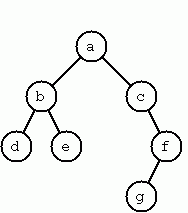

*A binary tree is either empty or it is composed of a root element and
two successors, which are binary trees themselves.*

In OCaml, one can define a new type `binary_tree` that carries an
arbitrary value of type `'a` (thus is polymorphic) at each node.

```ocaml
# type 'a binary_tree =
  | Empty
  | Node of 'a * 'a binary_tree * 'a binary_tree;;
type 'a binary_tree = Empty | Node of 'a * 'a binary_tree * 'a binary_tree
```

An example of tree carrying `char` data is:

```ocaml
# let example_tree =
  Node ('a', Node ('b', Node ('d', Empty, Empty), Node ('e', Empty, Empty)),
       Node ('c', Empty, Node ('f', Node ('g', Empty, Empty), Empty)));;
val example_tree : char binary_tree =
  Node ('a', Node ('b', Node ('d', Empty, Empty), Node ('e', Empty, Empty)),
   Node ('c', Empty, Node ('f', Node ('g', Empty, Empty), Empty)))
```

In OCaml, the strict type discipline *guarantees* that, if you get a
value of type `binary_tree`, then it must have been created with the two
constructors `Empty` and `Node`.

In a completely balanced binary tree, the following property holds for
every node: The number of nodes in its left subtree and the number of
nodes in its right subtree are almost equal, which means their
difference is not greater than one.

Write a function `cbal_tree` to construct completely balanced binary
trees for a given number of nodes. The function should generate all
solutions via backtracking. Put the letter `'x'` as information into all
nodes of the tree.

```ocaml
# cbal_tree 4;;
- : char binary_tree/2 list =
[Node ('x', Node ('x', Empty, Empty),
  Node ('x', Node ('x', Empty, Empty), Empty));
 Node ('x', Node ('x', Empty, Empty),
  Node ('x', Empty, Node ('x', Empty, Empty)));
 Node ('x', Node ('x', Node ('x', Empty, Empty), Empty),
  Node ('x', Empty, Empty));
 Node ('x', Node ('x', Empty, Node ('x', Empty, Empty)),
  Node ('x', Empty, Empty))]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex44
:class: dropdown
:label: sol44

```ocaml
# (* Build all trees with given [left] and [right] subtrees. *)
  let add_trees_with left right all =
    let add_right_tree all l =
      List.fold_left (fun a r -> Node ('x', l, r) :: a) all right in
    List.fold_left add_right_tree all left

  let rec cbal_tree n =
    if n = 0 then [Empty]
    else if n mod 2 = 1 then
      let t = cbal_tree (n / 2) in
      add_trees_with t t []
    else (* n even: n-1 nodes for the left & right subtrees altogether. *)
      let t1 = cbal_tree (n / 2 - 1) in
      let t2 = cbal_tree (n / 2) in
      add_trees_with t1 t2 (add_trees_with t2 t1 []);;
val add_trees_with :
  char binary_tree list ->
  char binary_tree list -> char binary_tree list -> char binary_tree list =
  <fun>
val cbal_tree : int -> char binary_tree list = <fun>
```
:::

:::{exercise} Symmetric Binary Trees 🟡
:label: ex45

**Tags:** `binary-tree`

Let us call a binary tree symmetric if you can draw a vertical line
through the root node and then the right subtree is the mirror image of
the left subtree. Write a function `is_symmetric` to check whether a
given binary tree is symmetric.

**Hint:** Write a function `is_mirror` first to check whether one tree
 is the mirror image of another. We are only interested in the
 structure, not in the contents of the nodes.
:::

In [ ]:
(* Answer here *)

:::{solution} ex45
:class: dropdown
:label: sol45

```ocaml
# let rec is_mirror t1 t2 =
    match t1, t2 with
    | Empty, Empty -> true
    | Node(_, l1, r1), Node(_, l2, r2) ->
       is_mirror l1 r2 && is_mirror r1 l2
    | _ -> false

  let is_symmetric = function
    | Empty -> true
    | Node(_, l, r) -> is_mirror l r;;
val is_mirror : 'a binary_tree -> 'b binary_tree -> bool = <fun>
val is_symmetric : 'a binary_tree -> bool = <fun>
```
:::

:::{exercise} Binary Search Trees (Dictionaries) 🟡
:label: ex46

**Tags:** `binary-tree`

Construct a 
[binary search tree](http://en.wikipedia.org/wiki/Binary_search_tree) 
from a list of integer numbers.

```ocaml
# construct [3; 2; 5; 7; 1];;
- : int binary_tree =
Node (3, Node (2, Node (1, Empty, Empty), Empty),
 Node (5, Empty, Node (7, Empty, Empty)))
```

Then use this function to test the solution of the previous problem.

```ocaml
# is_symmetric (construct [5; 3; 18; 1; 4; 12; 21]);;
- : bool = true
# not (is_symmetric (construct [3; 2; 5; 7; 4]));;
- : bool = true
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex46
:class: dropdown
:label: sol46

```ocaml
# let rec insert tree x = match tree with
    | Empty -> Node (x, Empty, Empty)
    | Node (y, l, r) ->
       if x = y then tree
       else if x < y then Node (y, insert l x, r)
       else Node (y, l, insert r x)
  let construct l = List.fold_left insert Empty l;;
val insert : 'a binary_tree -> 'a -> 'a binary_tree = <fun>
val construct : 'a list -> 'a binary_tree = <fun>
```
:::

:::{exercise} Generate-and-Test Paradigm 🟡
:label: ex47

**Tags:** `binary-tree`

Apply the generate-and-test paradigm to construct all symmetric,
completely balanced binary trees with a given number of nodes.

```ocaml
# sym_cbal_trees 5;;
- : char binary_tree list =
[Node ('x', Node ('x', Node ('x', Empty, Empty), Empty),
  Node ('x', Empty, Node ('x', Empty, Empty)));
 Node ('x', Node ('x', Empty, Node ('x', Empty, Empty)),
  Node ('x', Node ('x', Empty, Empty), Empty))]
```

How many such trees are there with 57 nodes? Investigate about how many
solutions there are for a given number of nodes? What if the number is
even? Write an appropriate function.

```ocaml
# List.length (sym_cbal_trees 57);;
- : int = 256
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex47
:class: dropdown
:label: sol47

```ocaml
# let sym_cbal_trees n =
    List.filter is_symmetric (cbal_tree n);;
val sym_cbal_trees : int -> char binary_tree list = <fun>
```
:::

:::{exercise} Construct Height-Balanced Binary Trees 🟡
:label: ex48

**Tags:** `binary-tree`

In a height-balanced binary tree, the following property holds for every
node: The height of its left subtree and the height of its right subtree
are almost equal, which means their difference is not greater than one.

Write a function `hbal_tree` to construct height-balanced binary trees
for a given height. The function should generate all solutions via
backtracking. Put the letter `'x'` as information into all nodes of the
tree.


```ocaml
# let t = hbal_tree 3;;
val t : char binary_tree list =
  [Node ('x', Node ('x', Empty, Node ('x', Empty, Empty)),
    Node ('x', Empty, Node ('x', Empty, Empty)));
   Node ('x', Node ('x', Empty, Node ('x', Empty, Empty)),
    Node ('x', Node ('x', Empty, Empty), Empty));
   Node ('x', Node ('x', Empty, Node ('x', Empty, Empty)),
    Node ('x', Node ('x', Empty, Empty), Node ('x', Empty, Empty)));
   Node ('x', Node ('x', Node ('x', Empty, Empty), Empty),
    Node ('x', Empty, Node ('x', Empty, Empty)));
   Node ('x', Node ('x', Node ('x', Empty, Empty), Empty),
    Node ('x', Node ('x', Empty, Empty), Empty));
   Node ('x', Node ('x', Node ('x', Empty, Empty), Empty),
    Node ('x', Node ('x', Empty, Empty), Node ('x', Empty, Empty)));
   Node ('x', Node ('x', Node ('x', Empty, Empty), Node ('x', Empty, Empty)),
    Node ('x', Empty, Node ('x', Empty, Empty)));
   Node ('x', Node ('x', Node ('x', Empty, Empty), Node ('x', Empty, Empty)),
    Node ('x', Node ('x', Empty, Empty), Empty));
   Node ('x', Node ('x', Node ('x', Empty, Empty), Node ('x', Empty, Empty)),
    Node ('x', Node ('x', Empty, Empty), Node ('x', Empty, Empty)));
   Node ('x', Node ('x', Empty, Node ('x', Empty, Empty)),
    Node ('x', Empty, Empty));
   Node ('x', Node ('x', Node ('x', Empty, Empty), Empty),
    Node ('x', Empty, Empty));
   Node ('x', Node ('x', Node ('x', Empty, Empty), Node ('x', Empty, Empty)),
    Node ('x', Empty, Empty));
   Node ('x', Node ('x', Empty, Empty),
    Node ('x', Empty, Node ('x', Empty, Empty)));
   Node ('x', Node ('x', Empty, Empty),
    Node ('x', Node ('x', Empty, Empty), Empty));
   Node ('x', Node ('x', Empty, Empty),
    Node ('x', Node ('x', Empty, Empty), Node ('x', Empty, Empty)))]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex48
:class: dropdown
:label: sol48

```ocaml
# let rec hbal_tree n =
    if n = 0 then [Empty]
    else if n = 1 then [Node ('x', Empty, Empty)]
    else
    (* [add_trees_with left right trees] is defined in a question above. *)
      let t1 = hbal_tree (n - 1)
      and t2 = hbal_tree (n - 2) in
      add_trees_with t1 t1 (add_trees_with t1 t2 (add_trees_with t2 t1 []));;
val hbal_tree : int -> char binary_tree list = <fun>
```
:::

:::{exercise} Construct Height-Balanced Binary Trees With a Given Number of Nodes 🟡
:label: ex49

**Tags:** `binary-tree`

Consider a height-balanced binary tree of height `h`. What is the
maximum number of nodes it can contain? Clearly,
max_nodes = 2<sup>`h`</sup> - 1.

```ocaml
# let max_nodes h = 1 lsl h - 1;;
val max_nodes : int -> int = <fun>
```

## Minimum of nodes

However, what is the minimum number min_nodes? This question is more
difficult. Try to find a recursive statement and turn it into a function
`min_nodes` defined as follows: `min_nodes h` returns the minimum number
of nodes in a height-balanced binary tree of height `h`.

## Minimum height

On the other hand, we might ask: what are the minimum (resp. maximum)
height H a
height-balanced binary tree with N nodes can have?
`min_height` (resp. `max_height n`) returns
the minimum (resp. maximum) height of a height-balanced binary tree
with `n` nodes.

## Constructing trees

Now, we can attack the main problem: construct all the height-balanced
binary trees with a given number of nodes. `hbal_tree_nodes n` returns a
list of all height-balanced binary tree with `n` nodes.

Find out how many height-balanced trees exist for `n = 15`.

```ocaml
# List.length (hbal_tree_nodes 15);;
- : int = 1553
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex49
:class: dropdown
:label: sol49

```ocaml
# let rec min_nodes h =
    if h <= 0 then 0 
    else if h = 1 then 1
    else min_nodes (h - 1) + min_nodes (h - 2) + 1;;
val min_nodes : int -> int = <fun>
```
:::

:::{exercise} Count the Leaves of a Binary Tree 🟢
:label: ex50

**Tags:** `binary-tree`

A leaf is a node with no successors. Write a function `count_leaves` to
count them.

```ocaml
# count_leaves Empty;;
- : int = 0
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex50
:class: dropdown
:label: sol50

```ocaml
# let rec count_leaves = function
    | Empty -> 0
    | Node (_, Empty, Empty) -> 1
    | Node (_, l, r) -> count_leaves l + count_leaves r;;
val count_leaves : 'a binary_tree -> int = <fun>
```
:::

:::{exercise} Collect the Leaves of a Binary Tree in a List 🟢
:label: ex51

**Tags:** `binary-tree`

A leaf is a node with no successors. Write a function `leaves` to
collect them in a list.

```ocaml
# leaves Empty;;
- : 'a list = []
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex51
:class: dropdown
:label: sol51

```ocaml
# (* Having an accumulator acc prevents using inefficient List.append.
   * Every Leaf will be pushed directly into accumulator.
   * Not tail-recursive, but that is no problem since we have a binary tree and
   * and stack depth is logarithmic. *)
  let leaves t = 
    let rec leaves_aux t acc = match t with
      | Empty -> acc
      | Node (x, Empty, Empty) -> x :: acc
      | Node (x, l, r) -> leaves_aux l (leaves_aux r acc)
    in
    leaves_aux t [];;
val leaves : 'a binary_tree -> 'a list = <fun>
```
:::

:::{exercise} Collect the Internal Nodes of a Binary Tree in a List 🟢
:label: ex52

**Tags:** `binary-tree`

An internal node of a binary tree has either one or two non-empty
successors. Write a function `internals` to collect them in a list.

```ocaml
# internals (Node ('a', Empty, Empty));;
- : char list = []
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex52
:class: dropdown
:label: sol52

```ocaml
# (* Having an accumulator acc prevents using inefficient List.append.
   * Every internal node will be pushed directly into accumulator.
   * Not tail-recursive, but that is no problem since we have a binary tree and
   * and stack depth is logarithmic. *)
  let internals t = 
    let rec internals_aux t acc = match t with
      | Empty -> acc
      | Node (x, Empty, Empty) -> acc
      | Node (x, l, r) -> internals_aux l (x :: internals_aux r acc)
    in
    internals_aux t [];;
val internals : 'a binary_tree -> 'a list = <fun>
```
:::

:::{exercise} Collect the Nodes at a Given Level in a List 🟢
:label: ex53

**Tags:** `binary-tree`

A node of a binary tree is at level N if the path from the root to the
node has length N-1. The root node is at level 1. Write a function
`at_level t l` to collect all nodes of the tree `t` at level `l` in a
list.

```ocaml
# let example_tree =
  Node ('a', Node ('b', Node ('d', Empty, Empty), Node ('e', Empty, Empty)),
       Node ('c', Empty, Node ('f', Node ('g', Empty, Empty), Empty)));;
val example_tree : char binary_tree =
  Node ('a', Node ('b', Node ('d', Empty, Empty), Node ('e', Empty, Empty)),
   Node ('c', Empty, Node ('f', Node ('g', Empty, Empty), Empty)))
# at_level example_tree 2;;
- : char list = ['b'; 'c']
```

Using `at_level` it is easy to construct a function `levelorder` which
creates the level-order sequence of the nodes. However, there are more
efficient ways to do that.
:::

In [ ]:
(* Answer here *)

:::{solution} ex53
:class: dropdown
:label: sol53

```ocaml
# (* Having an accumulator acc prevents using inefficient List.append.
   * Every node at level N will be pushed directly into accumulator.
   * Not tail-recursive, but that is no problem since we have a binary tree and
   * and stack depth is logarithmic. *)
  let at_level t level =
    let rec at_level_aux t acc counter = match t with
      | Empty -> acc
      | Node (x, l, r) ->
        if counter=level then
          x :: acc
        else
          at_level_aux l (at_level_aux r acc (counter + 1)) (counter + 1)
    in
      at_level_aux t [] 1;;
val at_level : 'a binary_tree -> int -> 'a list = <fun>
```
:::

:::{exercise} Construct a Complete Binary Tree 🟡
:label: ex54

**Tags:** `binary-tree`

A *complete* binary tree with height H is defined as follows: The levels
1,2,3,...,H-1 contain the maximum number of nodes (i.e 2<sup>i-1</sup>
at the level i, note that we start counting the levels from 1 at the
root). In level H, which may contain less than the maximum possible
number of nodes, all the nodes are "left-adjusted". This means that in a
levelorder tree traversal all internal nodes come first, the leaves come
second, and empty successors (the nil's which are not really nodes!)
come last.

Particularly, complete binary trees are used as data structures (or
addressing schemes) for heaps.

We can assign an address number to each node in a complete binary tree
by enumerating the nodes in levelorder, starting at the root with
number 1. In doing so, we realize that for every node X with address A
the following property holds: The address of X's left and right
successors are 2\*A and 2\*A+1, respectively, supposed the successors do
exist. This fact can be used to elegantly construct a complete binary
tree structure. Write a function `is_complete_binary_tree` with the
following specification: `is_complete_binary_tree n t` returns `true`
iff `t` is a complete binary tree with `n` nodes.

```ocaml
# complete_binary_tree [1; 2; 3; 4; 5; 6];;
- : int binary_tree =
Node (1, Node (2, Node (4, Empty, Empty), Node (5, Empty, Empty)),
 Node (3, Node (6, Empty, Empty), Empty))
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex54
:class: dropdown
:label: sol54

```ocaml
# let rec split_n lst acc n = match (n, lst) with
    | (0, _) -> (List.rev acc, lst)
    | (_, []) -> (List.rev acc, [])
    | (_, h :: t) -> split_n t (h :: acc) (n-1)

  let rec myflatten p c = 
    match (p, c) with
    | (p, []) -> List.map (fun x -> Node (x, Empty, Empty)) p
    | (x :: t, [y]) -> Node (x, y, Empty) :: myflatten t []
    | (ph :: pt, x :: y :: t) -> (Node (ph, x, y)) :: myflatten pt t
    | _ -> invalid_arg "myflatten"

  let complete_binary_tree = function
    | [] -> Empty
    | lst ->
       let rec aux l = function
         | [] -> []
         | lst -> let p, c = split_n lst [] (1 lsl l) in
                  myflatten p (aux (l + 1) c)
       in
         List.hd (aux 0 lst);;
val split_n : 'a list -> 'a list -> int -> 'a list * 'a list = <fun>
val myflatten : 'a list -> 'a binary_tree list -> 'a binary_tree list = <fun>
val complete_binary_tree : 'a list -> 'a binary_tree = <fun>
```
:::

:::{exercise} Layout a Binary Tree (1) 🟡
:label: ex55

**Tags:** `binary-tree`

As a preparation for drawing the tree, a layout algorithm is required to
determine the position of each node in a rectangular grid. Several
layout methods are conceivable, one of them is shown in the illustration.


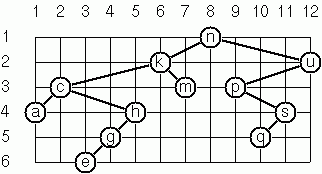

In this layout strategy, the position of a node v is obtained by the
following two rules:

* *x(v)* is equal to the position of the node v in the *inorder*
 sequence;
* *y(v)* is equal to the depth of the node *v* in the tree.

In order to store the position of the nodes, we will enrich the value
at each node with the position `(x,y)`.

The tree pictured above is
```ocaml
# let example_layout_tree =
  let leaf x = Node (x, Empty, Empty) in
  Node ('n', Node ('k', Node ('c', leaf 'a',
                           Node ('h', Node ('g', leaf 'e', Empty), Empty)),
                 leaf 'm'),
       Node ('u', Node ('p', Empty, Node ('s', leaf 'q', Empty)), Empty));;
val example_layout_tree : char binary_tree =
  Node ('n',
   Node ('k',
    Node ('c', Node ('a', Empty, Empty),
     Node ('h', Node ('g', Node ('e', Empty, Empty), Empty), Empty)),
    Node ('m', Empty, Empty)),
   Node ('u', Node ('p', Empty, Node ('s', Node ('q', Empty, Empty), Empty)),
    Empty))
```

```ocaml
# layout_binary_tree_1 example_layout_tree;;
- : (char * int * int) binary_tree =
Node (('n', 8, 1),
 Node (('k', 6, 2),
  Node (('c', 2, 3), Node (('a', 1, 4), Empty, Empty),
   Node (('h', 5, 4),
    Node (('g', 4, 5), Node (('e', 3, 6), Empty, Empty), Empty), Empty)),
  Node (('m', 7, 3), Empty, Empty)),
 Node (('u', 12, 2),
  Node (('p', 9, 3), Empty,
   Node (('s', 11, 4), Node (('q', 10, 5), Empty, Empty), Empty)),
  Empty))
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex55
:class: dropdown
:label: sol55

```ocaml
# let layout_binary_tree_1 t =
    let rec layout depth x_left = function
      (* This function returns a pair: the laid out tree and the first
       * free x location *)
      | Empty -> (Empty, x_left)
      | Node (v,l,r) ->
         let (l', l_x_max) = layout (depth + 1) x_left l in
         let (r', r_x_max) = layout (depth + 1) (l_x_max + 1) r in
           (Node ((v, l_x_max, depth), l', r'), r_x_max)
    in
      fst (layout 1 1 t);;
val layout_binary_tree_1 : 'a binary_tree -> ('a * int * int) binary_tree =
  <fun>
```
:::

:::{exercise} Layout a Binary Tree (2) 🟡
:label: ex56

**Tags:** `binary-tree`

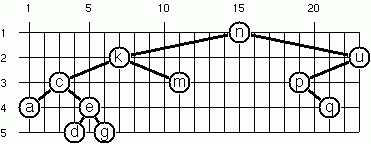

An alternative layout method is depicted in this illustration. Find
out the rules and write the corresponding OCaml function.

**Hint:** On a given level, the horizontal distance between
neighbouring nodes is constant.

The tree shown is 
```ocaml
# let example_layout_tree =
  let leaf x = Node (x, Empty, Empty) in
  Node ('n', Node ('k', Node ('c', leaf 'a',
                           Node ('e', leaf 'd', leaf 'g')),
                 leaf 'm'),
       Node ('u', Node ('p', Empty, leaf 'q'), Empty));;
val example_layout_tree : char binary_tree =
  Node ('n',
   Node ('k',
    Node ('c', Node ('a', Empty, Empty),
     Node ('e', Node ('d', Empty, Empty), Node ('g', Empty, Empty))),
    Node ('m', Empty, Empty)),
   Node ('u', Node ('p', Empty, Node ('q', Empty, Empty)), Empty))
```

```ocaml
# layout_binary_tree_2 example_layout_tree ;;
- : (char * int * int) binary_tree =
Node (('n', 15, 1),
 Node (('k', 7, 2),
  Node (('c', 3, 3), Node (('a', 1, 4), Empty, Empty),
   Node (('e', 5, 4), Node (('d', 4, 5), Empty, Empty),
    Node (('g', 6, 5), Empty, Empty))),
  Node (('m', 11, 3), Empty, Empty)),
 Node (('u', 23, 2),
  Node (('p', 19, 3), Empty, Node (('q', 21, 4), Empty, Empty)), Empty))
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex56
:class: dropdown
:label: sol56

```ocaml
# let layout_binary_tree_2 t =
    let rec height = function
      | Empty -> 0
      | Node (_, l, r) -> 1 + max (height l) (height r) in
    let tree_height = height t in
    let rec find_missing_left depth = function
      | Empty -> tree_height - depth
      | Node (_, l, _) -> find_missing_left (depth + 1) l in
    let translate_dst = 1 lsl (find_missing_left 0 t) - 1 in
                        (* remember than 1 lsl a = 2ᵃ *)
    let rec layout depth x_root = function
      | Empty -> Empty
      | Node (x, l, r) ->
         let spacing = 1 lsl (tree_height - depth - 1) in
         let l' = layout (depth + 1) (x_root - spacing) l
         and r' = layout (depth + 1) (x_root + spacing) r in
           Node((x, x_root, depth), l',r') in
    layout 1 ((1 lsl (tree_height - 1)) - translate_dst) t;;
val layout_binary_tree_2 : 'a binary_tree -> ('a * int * int) binary_tree =
  <fun>
```
:::

:::{exercise} Layout a Binary Tree (3) 🔴
:label: ex57

**Tags:** `binary-tree`

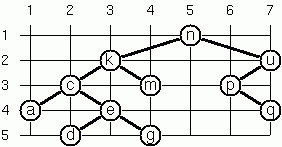

Yet another layout strategy is shown in the above illustration. The
method yields a very compact layout while maintaining a certain symmetry
in every node. Find out the rules and write the corresponding
predicate.

**Hint:** Consider the horizontal distance between a node and its successor
nodes. How tight can you pack together two subtrees to construct the
combined binary tree? This is a difficult problem. Don't give up too
early!

```ocaml
# let example_layout_tree =
  let leaf x = Node (x, Empty, Empty) in
  Node ('n', Node ('k', Node ('c', leaf 'a',
                           Node ('h', Node ('g', leaf 'e', Empty), Empty)),
                 leaf 'm'),
       Node ('u', Node ('p', Empty, Node ('s', leaf 'q', Empty)), Empty));;
val example_layout_tree : char binary_tree =
  Node ('n',
   Node ('k',
    Node ('c', Node ('a', Empty, Empty),
     Node ('h', Node ('g', Node ('e', Empty, Empty), Empty), Empty)),
    Node ('m', Empty, Empty)),
   Node ('u', Node ('p', Empty, Node ('s', Node ('q', Empty, Empty), Empty)),
    Empty))
# layout_binary_tree_3 example_layout_tree ;;
- : (char * int * int) binary_tree =
Node (('n', 5, 1),
 Node (('k', 3, 2),
  Node (('c', 2, 3), Node (('a', 1, 4), Empty, Empty),
   Node (('h', 3, 4),
    Node (('g', 2, 5), Node (('e', 1, 6), Empty, Empty), Empty), Empty)),
  Node (('m', 4, 3), Empty, Empty)),
 Node (('u', 7, 2),
  Node (('p', 6, 3), Empty,
   Node (('s', 7, 4), Node (('q', 6, 5), Empty, Empty), Empty)),
  Empty))
```

Which layout do you like most?
:::

In [ ]:
(* Answer here *)

:::{solution} ex57
:class: dropdown
:label: sol57

```ocaml
# let layout_binary_tree_3 =
    let rec translate_x d = function
      | Empty -> Empty
      | Node ((v, x, y), l, r) ->
         Node ((v, x + d, y), translate_x d l, translate_x d r) in
    (* Distance between a left subtree given by its right profile [lr]
       and a right subtree given by its left profile [rl]. *)
    let rec dist lr rl = match lr, rl with
      | lrx :: ltl, rlx :: rtl -> max (lrx - rlx) (dist ltl rtl)
      | [], _ | _, [] -> 0 in
    let rec merge_profiles p1 p2 = match p1, p2 with
      | x1 :: tl1, _ :: tl2 -> x1 :: merge_profiles tl1 tl2
      | [], _ -> p2
      | _, [] -> p1 in
    let rec layout depth = function
      | Empty -> ([], Empty, [])
      | Node (v, l, r) ->
         let (ll, l', lr) = layout (depth + 1) l in
         let (rl, r', rr) = layout (depth + 1) r in
         let d = 1 + dist lr rl / 2 in
         let ll = List.map (fun x -> x - d) ll
         and lr = List.map (fun x -> x - d) lr
         and rl = List.map ((+) d) rl
         and rr = List.map ((+) d) rr in
         (0 :: merge_profiles ll rl,
          Node((v, 0, depth), translate_x (-d) l', translate_x d r'),
          0 :: merge_profiles rr lr) in
    fun t -> let (l, t', _) = layout 1 t in
             let x_min = List.fold_left min 0 l in
             translate_x (1 - x_min) t';;
val layout_binary_tree_3 : 'a binary_tree -> ('a * int * int) binary_tree =
  <fun>
```
:::

:::{exercise} A String Representation of Binary Trees 🟡
:label: ex58

**Tags:** `binary-tree`

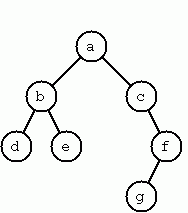

Somebody represents binary trees as strings of the following type (see
example): `"a(b(d,e),c(,f(g,)))"`.

* Write an OCaml function `string_of_tree` which generates this
 string representation,
 if the tree is given as usual (as `Empty` or `Node(x,l,r)` term).
 Then write a function `tree_of_string` which does this inverse;
 i.e. given the string
 representation, construct the tree in the usual form. Finally,
 combine the two predicates in a single function `tree_string` which
 can be used in both directions.
* Write the same predicate `tree_string` using difference lists and a
 single predicate `tree_dlist` which does the conversion between a
 tree and a difference list in both directions.

For simplicity, suppose the information in the nodes is a single letter
and there are no spaces in the string.

```ocaml
# let example_layout_tree =
  let leaf x = Node (x, Empty, Empty) in
    (Node ('a', Node ('b', leaf 'd', leaf 'e'),
     Node ('c', Empty, Node ('f', leaf 'g', Empty))));;
val example_layout_tree : char binary_tree =
  Node ('a', Node ('b', Node ('d', Empty, Empty), Node ('e', Empty, Empty)),
   Node ('c', Empty, Node ('f', Node ('g', Empty, Empty), Empty)))
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex58
:class: dropdown
:label: sol58

```ocaml
# let rec string_of_tree = function
    | Empty -> ""
    | Node(data, l, r) ->
       let data = String.make 1 data in
       match l, r with
       | Empty, Empty -> data
       | _, _ -> data ^ "(" ^ (string_of_tree l)
                 ^ "," ^ (string_of_tree r) ^ ")";;
val string_of_tree : char binary_tree -> string = <fun>
```
:::

:::{exercise} Preorder and Inorder Sequences of Binary Trees 🟡
:label: ex59

**Tags:** `binary-tree`

We consider binary trees with nodes that are identified by single
lower-case letters, as in the example of the previous problem.

1. Write functions `preorder` and `inorder`
   that construct the
   [preorder](https://en.wikipedia.org/wiki/Tree_traversal#Pre-order)
   and
   [inorder](https://en.wikipedia.org/wiki/Tree_traversal#In-order_.28symmetric.29)
 sequence of a given binary tree, respectively. The
 results should be atoms, e.g. 'abdecfg' for the preorder sequence of
 the example in the previous problem.
1. Can you use `preorder` from problem part 1 in the reverse
 direction; i.e. given a preorder sequence, construct a corresponding
 tree? If not, make the necessary arrangements.
1. If both the preorder sequence and the inorder sequence of the nodes
 of a binary tree are given, then the tree is determined
 unambiguously. Write a function `pre_in_tree` that does the job.
1. Solve problems 1 to 3 using
   [difference lists](https://en.wikipedia.org/wiki/Difference_list).
   Cool!  Use the
 function `timeit` (defined in problem “[Compare the two methods of
 calculating Euler&#39;s totient function.](#38)”) to compare the
 solutions.

What happens if the same character appears in more than one node. Try
for instance `pre_in_tree "aba" "baa"`.

```ocaml
# preorder (Node (1, Node (2, Empty, Empty), Empty));;
- : int list = [1; 2]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex59
:class: dropdown
:label: sol59

```ocaml
# let rec preorder = function
    | Empty -> []
    | Node (v, l, r) -> v :: (preorder l @ preorder r)
    let rec inorder = function
    | Empty -> []
    | Node (v, l, r) -> inorder l @ (v :: inorder r)
    let rec split_pre_in p i x accp acci = match (p, i) with
    | [], [] -> (List.rev accp, List.rev acci), ([], [])
    | h1 :: t1, h2 :: t2 ->
       if x = h2 then
         (List.tl (List.rev (h1 :: accp)), t1),
         (List.rev (List.tl (h2 :: acci)), t2)
       else
         split_pre_in t1 t2 x (h1 :: accp) (h2 :: acci)
    | _ -> assert false
    let rec pre_in_tree p i = match (p, i) with
    | [], [] -> Empty
    | (h1 :: t1), (h2 :: t2) ->
       let (lp, rp), (li, ri) = split_pre_in p i h1 [] [] in
         Node (h1, pre_in_tree lp li, pre_in_tree rp ri)
    | _ -> invalid_arg "pre_in_tree";;
val preorder : 'a binary_tree -> 'a list = <fun>
val inorder : 'a binary_tree -> 'a list = <fun>
val split_pre_in :
  'a list ->
  'a list ->
  'a -> 'a list -> 'a list -> ('a list * 'a list) * ('a list * 'a list) =
  <fun>
val pre_in_tree : 'a list -> 'a list -> 'a binary_tree = <fun>
```
:::

:::{exercise} Dotstring Representation of Binary Trees 🟡
:label: ex60

**Tags:** `binary-tree`

We consider again binary trees with nodes that are identified by single
lower-case letters, as in the example of problem “[A string
representation of binary trees](#67)”. Such a tree can be
represented by the preorder sequence of its nodes in which dots (.) are
inserted where an empty subtree (nil) is encountered during the tree
traversal. For example, the tree shown in problem “[A string
representation of binary trees](#67)” is represented as
'abd..e..c.fg...'. First, try to establish a syntax (BNF or syntax
diagrams) and then write a function `tree_dotstring` which does the
conversion in both directions. Use difference lists.
:::

In [ ]:
(* Answer here *)

:::{solution} ex60
:class: dropdown
:label: sol60

```ocaml
(* solution pending *)
```
:::

:::{exercise} Tree Construction From a Node String 🟡
:label: ex61

**Tags:** `multiway-tree`

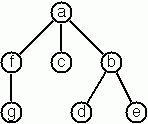

*A multiway tree is composed of a root element and a (possibly empty)
set of successors which are multiway trees themselves. A multiway tree
is never empty. The set of successor trees is sometimes called a
forest.*

To represent multiway trees, we will use the following type which is a
direct translation of the definition:

```ocaml
# type 'a mult_tree = T of 'a * 'a mult_tree list;;
type 'a mult_tree = T of 'a * 'a mult_tree list
```

The example tree depicted opposite is therefore represented by the
following OCaml expression:

```ocaml
# T ('a', [T ('f', [T ('g', [])]); T ('c', []); T ('b', [T ('d', []); T ('e', [])])]);;
- : char mult_tree =
T ('a',
 [T ('f', [T ('g', [])]); T ('c', []); T ('b', [T ('d', []); T ('e', [])])])
```

We suppose that the nodes of a multiway tree contain single characters.
In the depth-first order sequence of its nodes, a special character `^`
has been inserted whenever, during the tree traversal, the move is a
backtrack to the previous level.

By this rule, the tree in the figure opposite is represented as:
`afg^^c^bd^e^^^`.

Write functions `string_of_tree : char mult_tree -> string` to construct
the string representing the tree and
`tree_of_string : string -> char mult_tree` to construct the tree when
the string is given.


```ocaml
# let t = T ('a', [T ('f', [T ('g', [])]); T ('c', []);
          T ('b', [T ('d', []); T ('e', [])])]);;
val t : char mult_tree =
  T ('a',
   [T ('f', [T ('g', [])]); T ('c', []); T ('b', [T ('d', []); T ('e', [])])])
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex61
:class: dropdown
:label: sol61

```ocaml
# (* We could build the final string by string concatenation but
     this is expensive due to the number of operations.  We use a
     buffer instead. *)
  let rec add_string_of_tree buf (T (c, sub)) =
    Buffer.add_char buf c;
    List.iter (add_string_of_tree buf) sub;
    Buffer.add_char buf '^';;
val add_string_of_tree : Buffer.t -> char mult_tree -> unit = <fun>

# let string_of_tree t =
    let buf = Buffer.create 128 in
    add_string_of_tree buf t;
    Buffer.contents buf;;

val string_of_tree : char mult_tree -> string = <fun>

# let tree_of_string s =
    let rec parse_node chars =
      match chars with
      | [] -> failwith "Unexpected end of input (expecting node)"
      | c :: rest ->
          let (children, rest') = parse_children rest in
          (T (c, children), rest')
    and parse_children chars =
      match chars with
      | [] -> failwith "Unexpected end of input (expecting ^)"
      | '^' :: rest -> ([], rest)
      | _ ->
          let (child, rest') = parse_node chars in
          let (siblings, rest'') = parse_children rest' in
          (child :: siblings, rest'')
    in
    let (tree, remaining) = parse_node (List.of_seq (String.to_seq s)) in
    match remaining with
    | [] -> tree
    | _ -> failwith "Extra input after tree";;
val tree_of_string : string -> char mult_tree = <fun>
```
:::

:::{exercise} Count the Nodes of a Multiway Tree 🟢
:label: ex62

**Tags:** `multiway-tree`

```ocaml
# count_nodes (T ('a', [T ('f', []) ]));;
- : int = 2
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex62
:class: dropdown
:label: sol62

```ocaml
# let rec count_nodes (T (_, sub)) =
    List.fold_left (fun n t -> n + count_nodes t) 1 sub;;
val count_nodes : 'a mult_tree -> int = <fun>
```
:::

:::{exercise} Determine the Internal Path Length of a Tree 🟢
:label: ex63

**Tags:** `multiway-tree`

We define the internal path length of a multiway tree as the total sum
of the path lengths from the root to all nodes of the tree. By this
definition, the tree `t` in the figure of the previous problem has an
internal path length of 9. Write a function `ipl tree` that returns the
internal path length of `tree`.

```ocaml
# ipl t;;
- : int = 9
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex63
:class: dropdown
:label: sol63

```ocaml
# let rec ipl_sub len (T(_, sub)) =
    (* [len] is the distance of the current node to the root.  Add the
       distance of all sub-nodes. *)
    List.fold_left (fun sum t -> sum + ipl_sub (len + 1) t) len sub
  let ipl t = ipl_sub 0 t;;
val ipl_sub : int -> 'a mult_tree -> int = <fun>
val ipl : 'a mult_tree -> int = <fun>
```
:::

:::{exercise} Construct the Bottom-Up Order Sequence of the Tree Nodes 🟢
:label: ex64

**Tags:** `multiway-tree`

Write a function `bottom_up t` which constructs the bottom-up sequence
of the nodes of the multiway tree `t`.

```ocaml
# bottom_up (T ('a', [T ('b', [])]));;
- : char list = ['b'; 'a']
# bottom_up t;;
- : char list = ['g'; 'f'; 'c'; 'd'; 'e'; 'b'; 'a']
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex64
:class: dropdown
:label: sol64

```ocaml
# let rec prepend_bottom_up (T (c, sub)) l =
    List.fold_right (fun t l -> prepend_bottom_up t l) sub (c :: l)
  let bottom_up t = prepend_bottom_up t [];;
val prepend_bottom_up : 'a mult_tree -> 'a list -> 'a list = <fun>
val bottom_up : 'a mult_tree -> 'a list = <fun>
```
:::

:::{exercise} Lisp-Like Tree Representation 🟡
:label: ex65

**Tags:** `multiway-tree`

There is a particular notation for multiway trees in Lisp. The
picture shows how multiway tree structures are represented in Lisp.

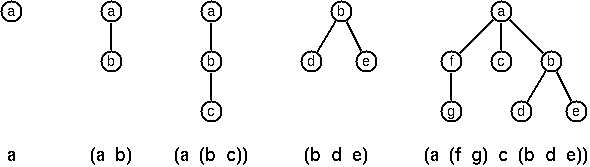

Note that in the "lispy" notation a node with successors (children) in
the tree is always the first element in a list, followed by its
children. The "lispy" representation of a multiway tree is a sequence of
atoms and parentheses '(' and ')'. This is very close to the way trees
are represented in OCaml, except that no constructor `T` is used. Write
a function `lispy : char mult_tree -> string` that returns the
lispy notation of the tree.

```ocaml
# lispy (T ('a', []));;
- : string = "a"
# lispy (T ('a', [T ('b', [])]));;
- : string = "(a b)"
# lispy t;;
- : string = "(a (f g) c (b d e))"
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex65
:class: dropdown
:label: sol65

```ocaml
# let rec add_lispy buf = function
    | T(c, []) -> Buffer.add_char buf c
    | T(c, sub) ->
       Buffer.add_char buf '(';
       Buffer.add_char buf c;
       List.iter (fun t -> Buffer.add_char buf ' '; add_lispy buf t) sub;
       Buffer.add_char buf ')'
  let lispy t =
    let buf = Buffer.create 128 in
    add_lispy buf t;
    Buffer.contents buf;;
val add_lispy : Buffer.t -> char mult_tree -> unit = <fun>
val lispy : char mult_tree -> string = <fun>
```
:::

:::{exercise} Conversions 🟢
:label: ex66

**Tags:** `graph`

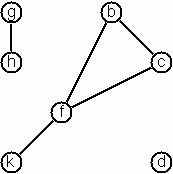

*A graph is defined as a set of nodes and a set of edges, where each
edge is a pair of different nodes.*

There are several ways to represent graphs in OCaml.

* One method is to list all edges, an edge being a pair of nodes. In
 this form, the graph depicted above is represented as the
 following expression:

```ocaml
# [('h', 'g'); ('k', 'f'); ('f', 'b'); ('f', 'c'); ('c', 'b')];;
- : (char * char) list =
[('h', 'g'); ('k', 'f'); ('f', 'b'); ('f', 'c'); ('c', 'b')]
```

We call this **edge-clause form**. Obviously, isolated nodes cannot
be represented.


* Another method is to represent the whole graph as one data object.
 According to the definition of the graph as a pair of two sets
 (nodes and edges), we may use the following OCaml type:

```ocaml
# type 'a graph_term = {nodes : 'a list;  edges : ('a * 'a) list};;
type 'a graph_term = { nodes : 'a list; edges : ('a * 'a) list; }
```

Then, the above example graph is represented by:

```ocaml
# let example_graph =
  {nodes = ['b'; 'c'; 'd'; 'f'; 'g'; 'h'; 'k'];
   edges = [('h', 'g'); ('k', 'f'); ('f', 'b'); ('f', 'c'); ('c', 'b')]};;
val example_graph : char graph_term =
  {nodes = ['b'; 'c'; 'd'; 'f'; 'g'; 'h'; 'k'];
   edges = [('h', 'g'); ('k', 'f'); ('f', 'b'); ('f', 'c'); ('c', 'b')]}
```

We call this **graph-term form**. Note, that the lists are kept
sorted, they are really sets, without duplicated elements. Each edge
appears only once in the edge list; i.e. an edge from a node x to
another node y is represented as `(x, y)`, the couple `(y, x)` is not
present. The **graph-term form is our default representation.** You
may want to define a similar type using sets instead of lists.

* A third representation method is to associate with each node the set
 of nodes that are adjacent to that node. We call this the
 **adjacency-list form**. In our example:

```ocaml
let adjacency_example = ['b', ['c'; 'f'];
                         'c', ['b'; 'f'];
                         'd', [];
                         'f', ['b'; 'c'; 'k'];
                         'g', ['h'];
                         'h', ['g'];
                         'k', ['f']
                         ];;
val adjacency_example : (char * char list) list =
  [('b', ['c'; 'f']); ('c', ['b'; 'f']); ('d', []); ('f', ['b'; 'c'; 'k']);
   ('g', ['h']); ('h', ['g']); ('k', ['f'])]
```

* The representations we introduced so far are well suited for automated
 processing, but their syntax is not very user-friendly. Typing the
 terms by hand is cumbersome and error-prone. We can define a more
 compact and "human-friendly" notation as follows: A graph (with char
 labelled nodes) is represented by a string of atoms and terms of the
 type X-Y. The atoms stand for isolated nodes, the X-Y terms describe
 edges. If an X appears as an endpoint of an edge, it is
 automatically defined as a node. Our example could be written as:

```ocaml
# "b-c f-c g-h d f-b k-f h-g";;
- : string = "b-c f-c g-h d f-b k-f h-g"
```

We call this the **human-friendly form**. As the example shows, the
list does not have to be sorted and may even contain the same edge
multiple times. Notice the isolated node `d`.

Write functions to convert between the different graph representations.
With these functions, all representations are equivalent; i.e. for the
following problems you can always pick freely the most convenient form.
This problem is not particularly difficult, but it's a lot of work to
deal with all the special cases.
:::

In [ ]:
(* Answer here *)

:::{solution} ex66
:class: dropdown
:label: sol66

```ocaml
(* example pending *)
```
:::

:::{exercise} Path From One Node to Another One 🟡
:label: ex67

**Tags:** `graph`

Write a function `paths g a b` that returns all acyclic path `p` from
node `a` to node `b ≠ a` in the graph `g`. The function should return
the list of all paths via backtracking.

```ocaml
# let example_graph =
  {nodes = ['b'; 'c'; 'd'; 'f'; 'g'; 'h'; 'k'];
   edges = [('h', 'g'); ('k', 'f'); ('f', 'b'); ('f', 'c'); ('c', 'b')]};;
val example_graph : char graph_term =
  {nodes = ['b'; 'c'; 'd'; 'f'; 'g'; 'h'; 'k'];
   edges = [('h', 'g'); ('k', 'f'); ('f', 'b'); ('f', 'c'); ('c', 'b')]}
# paths example_graph 'f' 'b';;
- : char list list = [['f'; 'c'; 'b']; ['f'; 'b']]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex67
:class: dropdown
:label: sol67

```ocaml
# (* The datastructures used here are far from the most efficient ones
     but allow for a straightforward implementation. *)
  (* Returns all neighbors satisfying the condition. *)
  let neighbors g a cond =
    let edge l (b, c) = if b = a && cond c then c :: l
                        else if c = a && cond b then b :: l
                        else l in
    List.fold_left edge [] g.edges
  let rec list_path g a to_b = match to_b with
    | [] -> assert false (* [to_b] contains the path to [b]. *)
    | a' :: _ ->
       if a' = a then [to_b]
       else
         let n = neighbors g a' (fun c -> not (List.mem c to_b)) in
           List.concat_map (fun c -> list_path g a (c :: to_b)) n

  let paths g a b =
    assert(a <> b);
    list_path g a [b];;
val neighbors : 'a graph_term -> 'a -> ('a -> bool) -> 'a list = <fun>
val list_path : 'a graph_term -> 'a -> 'a list -> 'a list list = <fun>
val paths : 'a graph_term -> 'a -> 'a -> 'a list list = <fun>
```
:::

:::{exercise} Cycle From a Given Node 🟢
:label: ex68

**Tags:** `graph`

Write a functions `cycle g a` that returns a closed path (cycle) `p`
starting at a given node `a` in the graph `g`. The predicate should
return the list of all cycles via backtracking.

```ocaml
# let example_graph =
  {nodes = ['b'; 'c'; 'd'; 'f'; 'g'; 'h'; 'k'];
   edges = [('h', 'g'); ('k', 'f'); ('f', 'b'); ('f', 'c'); ('c', 'b')]};;
val example_graph : char graph_term =
  {nodes = ['b'; 'c'; 'd'; 'f'; 'g'; 'h'; 'k'];
   edges = [('h', 'g'); ('k', 'f'); ('f', 'b'); ('f', 'c'); ('c', 'b')]}
# cycles example_graph 'f';;
- : char list list =
[['f'; 'b'; 'c'; 'f']; ['f'; 'c'; 'f']; ['f'; 'c'; 'b'; 'f'];
 ['f'; 'b'; 'f']; ['f'; 'k'; 'f']]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex68
:class: dropdown
:label: sol68

```ocaml
# let cycles g a =
    let n = neighbors g a (fun _ -> true) in
    let p = List.concat_map (fun c -> list_path g a [c]) n in
    List.map (fun p -> p @ [a]) p;;
val cycles : 'a graph_term -> 'a -> 'a list list = <fun>
```
:::

:::{exercise} Construct All Spanning Trees 🟡
:label: ex69

**Tags:** `graph`

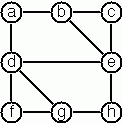

Write a function `s_tree g` to construct (by backtracking) all [spanning
trees](http://en.wikipedia.org/wiki/Spanning_tree) of a given graph `g`.
With this predicate, find out how many spanning trees there are for the
graph depicted to the left. The data of this example graph can be found
in the test below. When you have a correct solution for the `s_tree`
function, use it to define two other useful functions: `is_tree graph`
and `is_connected Graph`. Both are five-minutes tasks!

```ocaml
# let g = {nodes = ['a'; 'b'; 'c'; 'd'; 'e'; 'f'; 'g'; 'h'];
         edges = [('a', 'b'); ('a', 'd'); ('b', 'c'); ('b', 'e');
                  ('c', 'e'); ('d', 'e'); ('d', 'f'); ('d', 'g');
                  ('e', 'h'); ('f', 'g'); ('g', 'h')]};;
val g : char graph_term =
  {nodes = ['a'; 'b'; 'c'; 'd'; 'e'; 'f'; 'g'; 'h'];
   edges =
    [('a', 'b'); ('a', 'd'); ('b', 'c'); ('b', 'e'); ('c', 'e'); ('d', 'e');
     ('d', 'f'); ('d', 'g'); ('e', 'h'); ('f', 'g'); ('g', 'h')]}
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex69
:class: dropdown
:label: sol69

```ocaml
(* solution pending *);;
```
:::

:::{exercise} Construct the Minimal Spanning Tree 🟡
:label: ex70

**Tags:** `graph`

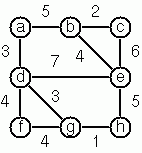

Write a function `ms_tree graph` to construct the minimal spanning tree
of a given labelled graph. A labelled graph will be represented as
follows:

```ocaml
# type ('a, 'b) labeled_graph = {nodes : 'a list;
                               labeled_edges : ('a * 'a * 'b) list};;
type ('a, 'b) labeled_graph = {
  nodes : 'a list;
  labeled_edges : ('a * 'a * 'b) list;
}
```

(Beware that from now on `nodes` and `edges` mask the previous fields of
the same name.)

**Hint:** Use the [algorithm of Prim](http://en.wikipedia.org/wiki/Prim%27s_algorithm).
A small modification of the solution of P83 does the trick. The data of the
example graph to the right can be found below.

```ocaml
# let g = {nodes = ['a'; 'b'; 'c'; 'd'; 'e'; 'f'; 'g'; 'h'];
         labeled_edges = [('a', 'b', 5); ('a', 'd', 3); ('b', 'c', 2);
                          ('b', 'e', 4); ('c', 'e', 6); ('d', 'e', 7);
                          ('d', 'f', 4); ('d', 'g', 3); ('e', 'h', 5);
                          ('f', 'g', 4); ('g', 'h', 1)]};;
val g : (char, int) labeled_graph =
  {nodes = ['a'; 'b'; 'c'; 'd'; 'e'; 'f'; 'g'; 'h'];
   labeled_edges =
    [('a', 'b', 5); ('a', 'd', 3); ('b', 'c', 2); ('b', 'e', 4);
     ('c', 'e', 6); ('d', 'e', 7); ('d', 'f', 4); ('d', 'g', 3);
     ('e', 'h', 5); ('f', 'g', 4); ('g', 'h', 1)]}
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex70
:class: dropdown
:label: sol70

```ocaml
(* solution pending *);;
```
:::

:::{exercise} Graph Isomorphism 🟡
:label: ex71

**Tags:** `graph`

Two graphs G1(N1,E1) and G2(N2,E2) are isomorphic if there is a
bijection f: N1 → N2 such that for any nodes X,Y of N1, X and Y are
adjacent if and only if f(X) and f(Y) are adjacent.

Write a function that determines whether two graphs are isomorphic.

**Hint:** Use an open-ended list to represent the function f.

```ocaml
# let g = {nodes = [1; 2; 3; 4; 5; 6; 7; 8];
         edges = [(1, 5); (1, 6); (1, 7); (2, 5); (2, 6); (2, 8); (3, 5);
                  (3, 7); (3, 8); (4, 6); (4, 7); (4, 8)]};;
val g : int graph_term =
  {nodes = [1; 2; 3; 4; 5; 6; 7; 8];
   edges =
    [(1, 5); (1, 6); (1, 7); (2, 5); (2, 6); (2, 8); (3, 5); (3, 7);
     (3, 8); (4, 6); (4, 7); (4, 8)]}
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex71
:class: dropdown
:label: sol71

```ocaml
(* solution pending *);;
```
:::

:::{exercise} Node Degree and Graph Coloration 🟡
:label: ex72

**Tags:** `graph`

* Write a function `degree graph node` that determines the degree of a
 given node.
* Write a function that generates a list of all nodes of a graph
 sorted according to decreasing degree.
* Use [Welsh-Powell&#39;s
 algorithm](http://en.wikipedia.org/wiki/Graph_coloring#Greedy_coloring)
 to paint the nodes of a graph in such a way that adjacent nodes have
 different colors.
:::

In [ ]:
(* Answer here *)

:::{solution} ex72
:class: dropdown
:label: sol72

```ocaml
(* example pending *);;
```
:::

:::{exercise} Depth-First Order Graph Traversal 🟡
:label: ex73

**Tags:** `graph`

Write a function that generates a
[depth-first order graph traversal](https://en.wikipedia.org/wiki/Depth-first_search)
sequence. The starting point should be specified, and the output should
be a list of nodes that are reachable from this starting point (in
depth-first order).

Specifically, the graph will be provided by its
[adjacency-list representation](https://en.wikipedia.org/wiki/Adjacency_list)
and you must create a module `M` with the following signature:

```ocaml
# module type GRAPH = sig
    type node = char
    type t
    val of_adjacency : (node * node list) list -> t
    val dfs_fold : t -> node -> ('a -> node -> 'a) -> 'a -> 'a
  end;;
module type GRAPH =
  sig
    type node = char
    type t
    val of_adjacency : (node * node list) list -> t
    val dfs_fold : t -> node -> ('a -> node -> 'a) -> 'a -> 'a
  end
```

where `M.dfs_fold g n f a` applies `f` on the nodes of the graph
`g` in depth first order, starting with node `n`.

```ocaml
# let g = M.of_adjacency
          ['u', ['v'; 'x'];
           'v',      ['y'];
           'w', ['z'; 'y'];
           'x',      ['v'];
           'y',      ['x'];
           'z',      ['z'];
          ];;
val g : M.t = <abstr>
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex73
:class: dropdown
:label: sol73

```ocaml
# module M : GRAPH = struct

    module Char_map = Map.Make (Char)
    type node = char
    type t = (node list) Char_map.t

    let of_adjacency l = 
      List.fold_right (fun (x, y) -> Char_map.add x y) l Char_map.empty

    type colors = White|Gray|Black

    type 'a state = {
        d : int Char_map.t; (*discovery time*)
      f : int Char_map.t; (*finishing time*)
      pred : char Char_map.t; (*predecessor*)
      color : colors Char_map.t; (*vertex colors*)
      acc : 'a; (*user specified type used by 'fold'*)
    }

    let dfs_fold g c fn acc =
      let rec dfs_visit t u {d; f; pred; color; acc} =
        let edge (t, state) v =
          if Char_map.find v state.color = White then
            dfs_visit t v {state with pred = Char_map.add v u state.pred}
          else  (t, state)
        in
        let t, {d; f; pred; color; acc} =
          let t = t + 1 in
          List.fold_left edge
            (t, {d = Char_map.add u t d; f;
                 pred; color = Char_map.add u Gray color; acc = fn acc u})
            (Char_map.find u g)
        in
        let t = t + 1 in
        t , {d; f = Char_map.add u t f; pred;
             color = Char_map.add u Black color; acc}
      in
      let v = List.fold_left (fun k (x, _) -> x :: k) []
                             (Char_map.bindings g) in
      let initial_state= 
        {d = Char_map.empty;
         f = Char_map.empty;
         pred = Char_map.empty;
         color = List.fold_right (fun x -> Char_map.add x White)
                                 v Char_map.empty;
         acc}
      in
      (snd (dfs_visit 0 c initial_state)).acc
  end;;
module M : GRAPH
```
:::

:::{exercise} Connected Components 🟡
:label: ex74

**Tags:** `graph`

Write a predicate that splits a graph into its [connected
components](http://en.wikipedia.org/wiki/Connected_component_%28graph_theory%29).
:::

In [ ]:
(* Answer here *)

:::{solution} ex74
:class: dropdown
:label: sol74

```ocaml
(* example pending *);;
```
:::

:::{exercise} Bipartite Graphs 🟡
:label: ex75

**Tags:** `graph`

Write a predicate that finds out whether a given graph is
[bipartite](http://en.wikipedia.org/wiki/Bipartite_graph).
:::

In [ ]:
(* Answer here *)

:::{solution} ex75
:class: dropdown
:label: sol75

```ocaml
(* example pending *);;
```
:::

:::{exercise} Generate K-Regular Simple Graphs With N Nodes 🔴
:label: ex76

**Tags:** `graph`

In a [K-regular graph](http://en.wikipedia.org/wiki/K-regular_graph) all
nodes have a degree of K; i.e. the number of edges incident in each node
is K. How many (non-isomorphic!) 3-regular graphs with 6 nodes are
there?

See also the [table of results](https://www.ic.unicamp.br/~meidanis/courses/mc336/2009s2/prolog/problemas/p94.txt).
:::

In [ ]:
(* Answer here *)

:::{solution} ex76
:class: dropdown
:label: sol76

```ocaml
(* example pending *);;
```
:::

:::{exercise} Eight Queens Problem 🟡
:label: ex77

This is a classical problem in computer science. The objective is to
place eight queens on a chessboard so that no two queens are attacking
each other; i.e., no two queens are in the same row, the same column, or
on the same diagonal.

**Hint:** Represent the positions of the queens as a list of numbers 1..N.
Example: `[4; 2; 7; 3; 6; 8; 5; 1]` means that the queen in the first column is
in row 4, the queen in the second column is in row 2, etc. Use the
generate-and-test paradigm.

```ocaml
# queens_positions 4;;
- : int list list = [[3; 1; 4; 2]; [2; 4; 1; 3]]
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex77
:class: dropdown
:label: sol77

```ocaml
# let possible row col used_rows usedD1 usedD2 =
    not (List.mem row used_rows
         || List.mem (row + col) usedD1
         || List.mem (row - col) usedD2)
         let queens_positions n =
    let rec aux row col used_rows usedD1 usedD2 =
      if col > n then [List.rev used_rows]
      else
        (if row < n then aux (row + 1) col used_rows usedD1 usedD2
         else [])
        @ (if possible row col used_rows usedD1 usedD2 then
             aux 1 (col + 1) (row :: used_rows) (row + col :: usedD1)
                 (row - col :: usedD2)
           else [])
    in aux 1 1 [] [] [];;
val possible : int -> int -> int list -> int list -> int list -> bool = <fun>
val queens_positions : int -> int list list = <fun>
```
:::

:::{exercise} Knight's Tour 🟡
:label: ex78

Another famous problem is this one: How can a knight jump on an N×N
chessboard in such a way that it visits every square exactly once?

**Hint:** Represent the squares by pairs of their coordinates `(x,y)`,
where both `x` and `y` are integers between 1 and N. Define the function
`jump n (x,y)` that returns all coordinates `(u,v)` to which a
knight can jump from `(x,y)` to on a `n`×`n` chessboard. And finally,
represent the solution of our problem as a list knight positions (the
knight's tour).
:::

In [ ]:
(* Answer here *)

:::{solution} ex78
:class: dropdown
:label: sol78

```ocaml
(* example pending *);;
```
:::

:::{exercise} Von Koch's Conjecture 🔴
:label: ex79

Several years ago I met a mathematician who was intrigued by a problem
for which he didn't know a solution. His name was Von Koch, and I don't
know whether the problem has been solved since.

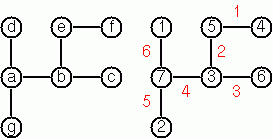

Anyway, the puzzle goes like this: Given a tree with N nodes (and hence
N-1 edges). Find a way to enumerate the nodes from 1 to N and,
accordingly, the edges from 1 to N-1 in such a way, that for each edge K
the difference of its node numbers equals to K. The conjecture is that
this is always possible.

For small trees the problem is easy to solve by hand. However, for
larger trees, and 14 is already very large, it is extremely difficult to
find a solution. And remember, we don't know for sure whether there is
always a solution!

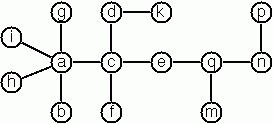

Write a function that calculates a numbering scheme for a given tree.
What is the solution for the larger tree pictured here?
:::

In [ ]:
(* Answer here *)

:::{solution} ex79
:class: dropdown
:label: sol79

```ocaml
(* example pending *);;
```
:::

:::{exercise} An Arithmetic Puzzle 🔴
:label: ex80

Given a list of integer numbers, find a correct way of inserting
arithmetic signs (operators) such that the result is a correct equation.
Example: With the list of numbers `[2; 3; 5; 7; 11]` we can form the
equations 2 - 3 + 5 + 7 = 11 or 2 = (3 * 5 + 7) / 11 (and ten others!).
:::

In [ ]:
(* Answer here *)

:::{solution} ex80
:class: dropdown
:label: sol80

```ocaml
(* example pending *);;
```
:::

:::{exercise} English Number Words 🟡
:label: ex81

On financial documents, like cheques, numbers must sometimes be written
in full words. Example: 175 must be written as one-seven-five. Write a
function `full_words` to print (non-negative) integer numbers in full
words.

```ocaml
# full_words 175;;
- : string = "one-seven-five"
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex81
:class: dropdown
:label: sol81

```ocaml
# let full_words =
    let digit = [|"zero"; "one"; "two"; "three"; "four"; "five"; "six";
                  "seven"; "eight"; "nine"|] in
    let rec words w n =
      if n = 0 then (match w with [] -> [digit.(0)] | _ -> w)
      else words (digit.(n mod 10) :: w) (n / 10)
    in
      fun n -> String.concat "-" (words [] n);;
val full_words : int -> string = <fun>
```
:::

:::{exercise} Syntax Checker 🟡
:label: ex82

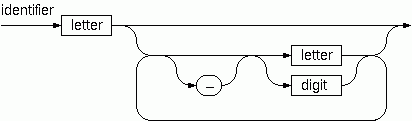

In a certain programming language (Ada) identifiers are defined by the
syntax diagram (railroad chart) opposite. Transform the syntax diagram
into a system of syntax diagrams which do not contain loops; i.e. which
are purely recursive. Using these modified diagrams, write a function
`identifier : string -> bool` that can check whether or not a given
string is a legal identifier.

```ocaml
# identifier "this-is-a-long-identifier";;
- : bool = true
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex82
:class: dropdown
:label: sol82

```ocaml
# let identifier =
    let is_letter c = 'a' <= c && c <= 'z' in
    let is_letter_or_digit c = is_letter c || ('0' <= c && c <= '9') in
    let rec is_valid s i not_after_dash =
      if i < 0 then not_after_dash
      else if is_letter_or_digit s.[i] then is_valid s (i - 1) true
      else if s.[i] = '-' && not_after_dash then is_valid s (i - 1) false
      else false in
    fun s -> (
        let n = String.length s in
      n > 0 && is_letter s.[n - 1] && is_valid s (n - 2) true);;
val identifier : string -> bool = <fun>
```
:::

:::{exercise} Sudoku 🟡
:label: ex83

Sudoku puzzles go like this:

```text
   Problem statement                 Solution

    .  .  4 | 8  .  . | .  1  7      9  3  4 | 8  2  5 | 6  1  7
            |         |                      |         |
    6  7  . | 9  .  . | .  .  .      6  7  2 | 9  1  4 | 8  5  3
            |         |                      |         |
    5  .  8 | .  3  . | .  .  4      5  1  8 | 6  3  7 | 9  2  4
    --------+---------+--------      --------+---------+--------
    3  .  . | 7  4  . | 1  .  .      3  2  5 | 7  4  8 | 1  6  9
            |         |                      |         |
    .  6  9 | .  .  . | 7  8  .      4  6  9 | 1  5  3 | 7  8  2
            |         |                      |         |
    .  .  1 | .  6  9 | .  .  5      7  8  1 | 2  6  9 | 4  3  5
    --------+---------+--------      --------+---------+--------
    1  .  . | .  8  . | 3  .  6      1  9  7 | 5  8  2 | 3  4  6
            |         |                      |         |
    .  .  . | .  .  6 | .  9  1      8  5  3 | 4  7  6 | 2  9  1
            |         |                      |         |
    2  4  . | .  .  1 | 5  .  .      2  4  6 | 3  9  1 | 5  7  8
```

Every spot in the puzzle belongs to a (horizontal) row and a (vertical)
column, as well as to one single 3x3 square (which we call "square" for
short). At the beginning, some of the spots carry a single-digit number
between 1 and 9. The problem is to fill the missing spots with digits in
such a way that every number between 1 and 9 appears exactly once in
each row, in each column, and in each square.

```ocaml
# (* The board representation is not imposed.  Here "0" stands for "." *);;
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex83
:class: dropdown
:label: sol83

```ocaml
# open Printf

  module Board = struct
    type t = int array (* 9×9, row-major representation.  A value of 0
                          means undecided. *)

    let is_valid c = c >= 1

    let get (b : t) (x, y) = b.(x + y * 9)

    let get_as_string (b : t) pos =
      let i = get b pos in
      if is_valid i then string_of_int i else "."

    let with_val (b : t) (x, y) v =
      let b = Array.copy b in
      b.(x + y * 9) <- v;
      b

    let of_list l : t =
      let b = Array.make 81 0 in
      List.iteri (fun y r -> List.iteri (fun x e ->
        b.(x + y * 9) <- if e >= 0 && e <= 9 then e else 0) r) l;
      b

    let print b =
      for y = 0 to 8 do
        for x = 0 to 8 do
          printf (if x = 0 then "%s" else if x mod 3 = 0 then " | %s"
                  else "  %s")  (get_as_string b (x, y))
        done;
        if y < 8 then
          if y mod 3 = 2 then printf "\n--------+---------+--------\n"
          else printf "\n        |         |        \n"
        else printf "\n"
      done

    let available b (x, y) =
      let avail = Array.make 10 true in
      for i = 0 to 8 do
        avail.(get b (x, i)) <- false;
        avail.(get b (i, y)) <- false;
      done;
      let sq_x = x - x mod 3 and sq_y = y - y mod 3 in
      for x = sq_x to sq_x + 2 do
        for y = sq_y to sq_y + 2 do
          avail.(get b (x, y)) <- false;
        done;
      done;
      let av = ref [] in
      for i = 1 (* not 0 *) to 9 do if avail.(i) then av := i :: !av done;
      !av

    let next (x,y) = if x < 8 then (x + 1, y) else (0, y + 1)

    (** Try to fill the undecided entries. *)
    let rec fill b ((x, y) as pos) =
      if y > 8 then Some b (* filled all entries *)
      else if is_valid(get b pos) then fill b (next pos)
      else match available b pos with
           | [] -> None (* no solution *)
           | l -> try_values b pos l
    and try_values b pos = function
      | v :: l ->
         (match fill (with_val b pos v) (next pos) with
          | Some _ as res -> res
          | None -> try_values b pos l)
      | [] -> None
  end

  let sudoku b = match Board.fill b (0, 0) with
    | Some b -> b
    | None -> failwith "sudoku: no solution";;
module Board :
  sig
    type t = int array
    val is_valid : int -> bool
    val get : t -> int * int -> int
    val get_as_string : t -> int * int -> string
    val with_val : t -> int * int -> int -> int array
    val of_list : int list list -> t
    val print : t -> unit
    val available : t -> int * int -> int list
    val next : int * int -> int * int
    val fill : t -> int * int -> t option
    val try_values : t -> int * int -> int list -> t option
  end
val sudoku : Board.t -> Board.t = <fun>
```
:::

:::{exercise} Nonograms 🔴
:label: ex84

Around 1994, a certain kind of puzzles was very popular in England. The
"Sunday Telegraph" newspaper wrote: "Nonograms are puzzles from Japan
and are currently published each week only in The Sunday Telegraph.
Simply use your logic and skill to complete the grid and reveal a
picture or diagram." As an OCaml programmer, you are in a better
situation: you can have your computer do the work!

The puzzle goes like this: Essentially, each row and column of a
rectangular bitmap is annotated with the respective lengths of its
distinct strings of occupied cells. The person who solves the puzzle
must complete the bitmap given only these lengths.

```text
          Problem statement:          Solution:

          |_|_|_|_|_|_|_|_| 3         |_|X|X|X|_|_|_|_| 3
          |_|_|_|_|_|_|_|_| 2 1       |X|X|_|X|_|_|_|_| 2 1
          |_|_|_|_|_|_|_|_| 3 2       |_|X|X|X|_|_|X|X| 3 2
          |_|_|_|_|_|_|_|_| 2 2       |_|_|X|X|_|_|X|X| 2 2
          |_|_|_|_|_|_|_|_| 6         |_|_|X|X|X|X|X|X| 6
          |_|_|_|_|_|_|_|_| 1 5       |X|_|X|X|X|X|X|_| 1 5
          |_|_|_|_|_|_|_|_| 6         |X|X|X|X|X|X|_|_| 6
          |_|_|_|_|_|_|_|_| 1         |_|_|_|_|X|_|_|_| 1
          |_|_|_|_|_|_|_|_| 2         |_|_|_|X|X|_|_|_| 2
           1 3 1 7 5 3 4 3             1 3 1 7 5 3 4 3
           2 1 5 1                     2 1 5 1
```

For the example above, the problem can be stated as the two lists
`[[3]; [2; 1]; [3; 2]; [2; 2]; [6]; [1; 5]; [6]; [1]; [2]]` and
`[[1; 2]; [3; 1]; [1; 5]; [7; 1]; [5]; [3]; [4]; [3]]` which give the "solid"
lengths of the rows and columns, top-to-bottom and left-to-right,
respectively. Published puzzles are larger than this example, e.g.
25×20, and apparently always have unique solutions.

<!-- $MDX skip -->
```ocaml
# solve [[3]; [2; 1]; [3; 2]; [2; 2]; [6]; [1; 5]; [6]; [1]; [2]]
      [[1; 2]; [3; 1]; [1; 5]; [7; 1]; [5]; [3]; [4]; [3]];;
```
:::

In [ ]:
(* Answer here *)

:::{solution} ex84
:class: dropdown
:label: sol84

```ocaml
# type element = Empty | X (* ensure we do not miss cases in patterns *);;
type element = Empty | X
```
:::

:::{exercise} Crossword Puzzle 🔴
:label: ex85

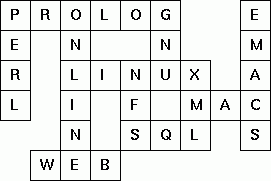

Given an empty (or almost empty) framework of a crossword puzzle and a
set of words. The problem is to place the words into the framework.

The particular crossword puzzle is specified in a text file which first
lists the words (one word per line) in an arbitrary order. Then, after
an empty line, the crossword framework is defined. In this framework
specification, an empty character location is represented by a dot (.).
In order to make the solution easier, character locations can also
contain predefined character values. The puzzle above is defined in the
file
[p7_09a.dat](https://sites.google.com/site/prologsite/prolog-problems/7/solutions-7/p7_09a.dat?attredirects=0&d=1),
other examples are
[p7_09b.dat](https://sites.google.com/site/prologsite/prolog-problems/7/solutions-7/p7_09b.dat?attredirects=0&d=1)
and
[p7_09d.dat](https://sites.google.com/site/prologsite/prolog-problems/7/solutions-7/p7_09d.dat?attredirects=0&d=1).
There is also an example of a puzzle
([p7_09c.dat](https://sites.google.com/site/prologsite/prolog-problems/7/solutions-7/p7_09c.dat?attredirects=0&d=1))
which does not have a solution.

Words are strings (character lists) of at least two characters. A
horizontal or vertical sequence of character places in the crossword
puzzle framework is called a site. Our problem is to find a compatible
way of placing words onto sites.

**Hints:**

1. The problem is not easy. You will need some time to thoroughly
 understand it. So, don't give up too early! And remember that the
 objective is a clean solution, not just a quick-and-dirty hack!
1. For efficiency reasons it is important, at least for larger puzzles,
 to sort the words and the sites in a particular order.
:::

In [ ]:
(* Answer here *)

:::{solution} ex85
:class: dropdown
:label: sol85

```ocaml
(* example pending *);;
```
:::

:::{exercise} Never-Ending Sequences 🟢
:label: ex86

**Tags:** `seq`

Lists are finite, meaning they always contain a finite number of elements. Sequences may
be finite or infinite.

The goal of this exercise is to define a type `'a stream` which only contains
infinite sequences. Using this type, define the following functions:
```ocaml
val hd : 'a stream -> 'a
(** Returns the first element of a stream *)
val tl : 'a stream -> 'a stream
(** Removes the first element of a stream *)
val take : int -> 'a stream -> 'a list
(** [take n seq] returns the n first values of [seq] *)
val unfold : ('a -> 'b * 'a) -> 'a -> 'b stream
(** Similar to Seq.unfold *)
val bang : 'a -> 'a stream
(** [bang x] produces an infinitely repeating sequence of [x] values. *)
val ints : int -> int stream
(* Similar to Seq.ints *)
val map : ('a -> 'b) -> 'a stream -> 'b stream
(** Similar to List.map and Seq.map *)
val filter: ('a -> bool) -> 'a stream -> 'a stream
(** Similar to List.filter and Seq.filter *)
val iter : ('a -> unit) -> 'a stream -> 'b
(** Similar to List.iter and Seq.iter *)
val to_seq : 'a stream -> 'a Seq.t
(** Translates an ['a stream] into an ['a Seq.t] *)
val of_seq : 'a Seq.t -> 'a stream
(** Translates an ['a Seq.t] into an ['a stream]
    @raise Failure if the input sequence is finite. *)
```
**Tip:** Use `let ... =` patterns.
:::

In [ ]:
(* Answer here *)

:::{solution} ex86
:class: dropdown
:label: sol86

```ocaml
type 'a cons = Cons of 'a * 'a stream
and 'a stream = unit -> 'a cons

let hd (seq : 'a stream) = let (Cons (x, _)) = seq () in x
let tl (seq : 'a stream) = let (Cons (_, seq)) = seq () in seq
let rec take n seq = if n = 0 then [] else let (Cons (x, seq)) = seq () in x :: take (n - 1) seq
let rec unfold f x () = let (y, x) = f x in Cons (y, unfold f x)
let bang x = unfold (fun x -> (x, x)) x
let ints x = unfold (fun x -> (x, x + 1)) x
let rec map f seq () = let (Cons (x, seq)) = seq () in Cons (f x, map f seq)
let rec filter p seq () = let (Cons (x, seq)) = seq () in let seq = filter p seq in if p x then Cons (x, seq) else seq ()
let rec iter f seq = let (Cons (x, seq)) = seq () in f x; iter f seq
let to_seq seq = Seq.unfold (fun seq -> Some (hd seq, tl seq)) seq
let rec of_seq seq () = match seq () with
| Seq.Nil -> failwith "Not a infinite sequence"
| Seq.Cons (x, seq) -> Cons (x, of_seq seq)
```
:::

:::{exercise} Diagonal of a Sequence of Sequences 🟡
:label: ex87

**Tags:** `seq`

Write a function `diag : 'a Seq.t Seq.t -> 'a Seq` that returns the _diagonal_
of a sequence of sequences. The returned sequence is formed as follows:
The first element of the returned sequence is the first element of the first
sequence; the second element of the returned sequence is the second element of
the second sequence; the third element of the returned sequence is the third
element of the third sequence; and so on.
:::

In [ ]:
(* Answer here *)

:::{solution} ex87
:class: dropdown
:label: sol87

```ocaml
let rec diag seq_seq () =
    let hds, tls = Seq.filter_map Seq.uncons seq_seq |> Seq.split in
    let hd, tl = Seq.uncons hds |> Option.map fst, Seq.uncons tls |> Option.map snd in
    let d = Option.fold ~none:Seq.empty ~some:diag tl in
    Option.fold ~none:Fun.id ~some:Seq.cons hd d ()
```
:::